# ACDADA — Notebook 01: Data Preprocessing & Feature Engineering

**Autonomous Cyber Deception & Adaptive Defense Agent**

This notebook handles:
1. Loading raw datasets (CICIDS2017, UNSW-NB15, Bot-IoT)
2. Exploratory Data Analysis (EDA)
3. Data cleaning (missing values, duplicates, infinity handling)
4. Feature engineering (encoding, normalization, selection)
5. Train/Val/Test splitting
6. Saving processed data for downstream notebooks

## Dataset Download Links

Download and place raw CSVs into `../data/raw/`

In [1]:
# ============================================================
# DATASET DOWNLOAD LINKS
# ============================================================
#
# 1. CIC-IDS-2017 (Network Intrusion Dataset)
#    https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
#    -> Download and extract to: ../data/raw/cicids2017/
#
# 2. UNSW-NB15
#    https://research.unsw.edu.au/projects/unsw-nb15-dataset
#    https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
#    -> Download and extract to: ../data/raw/unsw_nb15/
#
# 3. Bot-IoT Dataset
#    https://research.unsw.edu.au/projects/bot-iot-dataset
#    https://www.kaggle.com/datasets/vigneshvenkateswaran/bot-iot-dataset
#    -> Download and extract to: ../data/raw/bot_iot/
#
# BETH Dataset (supplementary):
#    https://www.kaggle.com/datasets/katehighnam/beth-dataset
#    -> Download and extract to: ../data/raw/beth/
#
# ============================================================
# DIRECTORY STRUCTURE AFTER DOWNLOAD:
# ../data/raw/
#   ├── cicids2017/        (CSV files from CICIDS2017)
#   ├── unsw_nb15/         (CSV files from UNSW-NB15)
#   ├── bot_iot/           (CSV files from Bot-IoT)
#   └── beth/              (CSV files from BETH)
# ============================================================

## 1. Imports & Configuration

In [2]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, LabelEncoder, RobustScaler
)
from sklearn.feature_selection import (
    mutual_info_classif, SelectKBest, VarianceThreshold
)
from sklearn.utils import resample
import joblib
import gc

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

def _looks_like_project_root(p: Path) -> bool:
    return (p / 'data' / 'raw').exists() and (p / 'notebooks').exists()

def find_project_root() -> Path:
    """
    Find the repo root robustly (works even if the Jupyter kernel CWD is '/').
    We look for a directory that contains both `data/raw/` and `notebooks/`.
    """
    # Manual override (recommended if auto-detection fails)
    override = os.getenv('ACDADA_PROJECT_ROOT')
    if override:
        p = Path(override).expanduser()
        if _looks_like_project_root(p):
            return p.resolve()

    candidates: list[Path] = []

    # 1) Start from common environment hints + current working directory
    for env_key in ('VSCODE_CWD', 'WORKSPACE_FOLDER', 'PWD'):
        v = os.getenv(env_key)
        if v:
            candidates.append(Path(v))
    candidates.append(Path.cwd())

    # 2) Walk parents of each candidate
    expanded: list[Path] = []
    for c in candidates:
        try:
            c = c.resolve()
        except Exception:
            pass
        expanded.append(c)
        expanded.extend(list(c.parents))

    # 3) WSL-style mounts and common dev-container locations
    #    (e.g. /mnt/d/Projects/ACDADA or /workspaces/ACDADA)
    if Path('/mnt').exists():
        for drive in Path('/mnt').glob('*'):
            for base in (drive / 'Projects', drive / 'projects', drive):
                repo = base / 'ACDADA'
                if _looks_like_project_root(repo):
                    expanded.append(repo)
        for base in (Path('/workspaces'), Path('/workspace')):
            repo = base / 'ACDADA'
            if _looks_like_project_root(repo):
                expanded.append(repo)

    # 4) Light scan from filesystem root (cheap: only checks a few common patterns)
    if os.name != 'nt':
        try:
            for top in Path('/').iterdir():
                if not top.is_dir():
                    continue
                for repo in (
                    top / 'ACDADA',
                    top / 'Projects' / 'ACDADA',
                    top / 'projects' / 'ACDADA',
                    top / 'workspaces' / 'ACDADA',
                    top / 'workspace' / 'ACDADA',
                ):
                    if _looks_like_project_root(repo):
                        expanded.append(repo)
        except Exception:
            pass

    # 5) Pick the first match (deduped, deterministic order)
    seen: set[str] = set()
    for p in expanded:
        try:
            rp = p.resolve()
        except Exception:
            rp = p
        key = str(rp)
        if key in seen:
            continue
        seen.add(key)
        if _looks_like_project_root(rp):
            return rp

    # 6) Fallback: nearest parent containing data/raw, else CWD
    for p in expanded:
        try:
            rp = p.resolve()
        except Exception:
            rp = p
        for parent in [rp, *rp.parents]:
            if (parent / 'data' / 'raw').exists():
                return parent

    return Path.cwd().resolve()

# Paths (absolute, derived from PROJECT_ROOT)
PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'OS: {os.name} | platform: {sys.platform}')
print(f'CWD: {Path.cwd()}')
print(f'Project root: {PROJECT_ROOT}')
print(f'Raw data directory: {RAW_DIR.resolve()}')
print(f'Processed data directory: {PROCESSED_DIR.resolve()}')
if not RAW_DIR.exists():
    print('\n[WARNING] `data/raw` was not found at the resolved PROJECT_ROOT.')
    print('          If you are using WSL/Docker, your repo path may be different inside that environment.')
    print('          Fix: set env var ACDADA_PROJECT_ROOT (examples):')
    print('            - WSL:    export ACDADA_PROJECT_ROOT="/mnt/d/Projects/ACDADA"')
    print('            - Docker: export ACDADA_PROJECT_ROOT="/workspaces/ACDADA"')

NumPy: 2.4.2
Pandas: 3.0.1
OS: nt | platform: win32
CWD: d:\Projects\ACDADA\notebooks
Project root: D:\Projects\ACDADA
Raw data directory: D:\Projects\ACDADA\data\raw
Processed data directory: D:\Projects\ACDADA\data\processed


In [3]:
# --- Environment sanity checks (helps debug dataset path issues) ---
print('\n' + '='*60)
print('ENVIRONMENT CHECK')
print('='*60)
print('Python executable:', sys.executable)
print('Python version:', sys.version.split()[0])
print('CWD:', Path.cwd())

candidates = [
    Path('/mnt/d/Projects/ACDADA'),            # common WSL mount for D:
    Path('/mnt/c/Users'),                     # sanity check WSL mount
    Path('/workspaces/ACDADA'),               # common devcontainer/codespaces
    Path('/workspace/ACDADA'),
    Path('/content'),                         # common hosted notebooks
    Path('D:/Projects/ACDADA'),               # Windows-style (will only exist on Windows kernels)
    Path('d:/Projects/ACDADA'),
 ]

print('\nCandidate repo roots (exists?):')
for p in candidates:
    try:
        print(f'  - {p}: {p.exists()}')
    except Exception as e:
        print(f'  - {p}: [error] {e}')

print('\nResolved RAW_DIR:', RAW_DIR)
print('RAW_DIR exists?:', RAW_DIR.exists())
cicids_path = RAW_DIR / 'cicids2017'
print('CICIDS path:', cicids_path)
print('CICIDS path exists?:', cicids_path.exists())
if cicids_path.exists():
    files = sorted(cicids_path.glob('*.csv'))
    print(f'CSV count in cicids2017/: {len(files)}')
    for f in files[:5]:
        print('  ', f.name)
else:
    print('\n[NOTE] If these paths are all False, your current kernel cannot see your Windows workspace.')
    print('       Fix: switch the notebook kernel to a local/WSL interpreter that has access to the repo,')
    print('       or set ACDADA_PROJECT_ROOT to the correct path *inside* this kernel environment.')


ENVIRONMENT CHECK
Python executable: d:\Projects\ACDADA\.venv\Scripts\python.exe
Python version: 3.12.6
CWD: d:\Projects\ACDADA\notebooks

Candidate repo roots (exists?):
  - \mnt\d\Projects\ACDADA: False
  - \mnt\c\Users: False
  - \workspaces\ACDADA: False
  - \workspace\ACDADA: False
  - \content: False
  - D:\Projects\ACDADA: True
  - d:\Projects\ACDADA: True

Resolved RAW_DIR: D:\Projects\ACDADA\data\raw
RAW_DIR exists?: True
CICIDS path: D:\Projects\ACDADA\data\raw\cicids2017
CICIDS path exists?: True
CSV count in cicids2017/: 8
   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   Friday-WorkingHours-Morning.pcap_ISCX.csv
   Monday-WorkingHours.pcap_ISCX.csv
   Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv


In [4]:
# --- Local Kernel Verification (Windows path visibility) ---
import sys
from pathlib import Path

print('sys.executable:', sys.executable)
win_cicids = Path(r'D:\Projects\ACDADA\data\raw\cicids2017')
print('Windows CICIDS path:', win_cicids)
print('Exists?:', win_cicids.exists())
if win_cicids.exists():
    files = sorted(win_cicids.glob('*.csv'))
    print('CSV count:', len(files))
    for f in files[:5]:
        print('  ', f.name)
else:
    print('If this is False, you are NOT running on the local Windows kernel that can see D:\\Projects.')

sys.executable: d:\Projects\ACDADA\.venv\Scripts\python.exe
Windows CICIDS path: D:\Projects\ACDADA\data\raw\cicids2017
Exists?: True
CSV count: 8
   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   Friday-WorkingHours-Morning.pcap_ISCX.csv
   Monday-WorkingHours.pcap_ISCX.csv
   Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv


---
## 2. Load CICIDS2017 Dataset

In [7]:
def load_cicids2017(data_dir: Path, nrows_per_file: int = None) -> pd.DataFrame:
    """
    Load all CICIDS2017 CSV files and concatenate into a single DataFrame.
    Handles the common issues: whitespace in column names, mixed dtypes.
    
    Args:
        data_dir: Path to the data directory
        nrows_per_file: Maximum rows to read from each file (None = all rows)
    """
    cicids_path = data_dir / 'cicids2017'
    csv_files = sorted(cicids_path.glob('*.csv'))
    
    if not csv_files:
        print(f'[WARNING] No CSV files found in {cicids_path}')
        return pd.DataFrame()
    
    print(f'Found {len(csv_files)} CICIDS2017 files:')
    for f in csv_files:
        print(f'  - {f.name} ({f.stat().st_size / 1e6:.1f} MB)')
    
    dfs = []
    for f in csv_files:
        try:
            df = pd.read_csv(f, low_memory=False, encoding='utf-8', nrows=nrows_per_file)
            # Strip whitespace from column names
            df.columns = df.columns.str.strip()
            dfs.append(df)
            print(f'  Loaded {f.name}: {df.shape}')
        except Exception as e:
            print(f'  [ERROR] Failed to load {f.name}: {e}')
    
    if not dfs:
        return pd.DataFrame()
    
    combined = pd.concat(dfs, ignore_index=True)
    print(f'\nCombined CICIDS2017 shape: {combined.shape}')
    print(f'Memory usage: {combined.memory_usage(deep=True).sum() / 1e6:.1f} MB')

    return combined

df_cicids = load_cicids2017(RAW_DIR, nrows_per_file=20_000)

if not df_cicids.empty:
    display(df_cicids.head())

Found 8 CICIDS2017 files:
  - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv (77.1 MB)
  - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv (76.9 MB)
  - Friday-WorkingHours-Morning.pcap_ISCX.csv (58.3 MB)
  - Monday-WorkingHours.pcap_ISCX.csv (176.9 MB)
  - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv (83.1 MB)
  - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv (52.0 MB)
  - Tuesday-WorkingHours.pcap_ISCX.csv (135.1 MB)
  - Wednesday-workingHours.pcap_ISCX.csv (225.2 MB)
  Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (20000, 79)
  Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (20000, 79)
  Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: (20000, 79)
  Loaded Monday-WorkingHours.pcap_ISCX.csv: (20000, 79)
  Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (20000, 79)
  Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (20000, 79)
  Loaded Tuesday-WorkingHours.pcap_ISCX.csv: (20000, 79)
  Loaded Wed

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 3. Load UNSW-NB15 Dataset

In [9]:
def _read_csv_with_encoding_fallback(path: Path, *, encodings=None, **kwargs) -> pd.DataFrame:
    """Read CSV trying multiple encodings (handles CP-1252/Latin-1 data dumps)."""
    if encodings is None:
        encodings = ('utf-8', 'utf-8-sig', 'cp1252', 'latin1')
    last_err = None
    for enc in encodings:
        try:
            return pd.read_csv(path, low_memory=False, encoding=enc, **kwargs)
        except UnicodeDecodeError as e:
            last_err = e
        except TypeError:
            # Older pandas may not support some kwargs we pass; retry without extras if needed.
            return pd.read_csv(path, low_memory=False, encoding=enc)
    raise last_err  # noqa: B904


def load_unsw_nb15(data_dir: Path, nrows_per_file: int = None) -> pd.DataFrame:
    """
    Load UNSW-NB15 dataset. Handles both single-file and multi-file variants.
    The dataset has predefined train/test splits — we load both and combine.
    
    Args:
        data_dir: Path to the data directory
        nrows_per_file: Maximum rows to read from each file (None = all rows)
    """
    unsw_path = data_dir / 'unsw_nb15'
    csv_files = sorted(unsw_path.glob('*.csv'))
    
    if not csv_files:
        print(f'[WARNING] No CSV files found in {unsw_path}')
        return pd.DataFrame()
    
    # Some CSVs in this folder are metadata, not flow records.
    skip_names = {
        'NUSW-NB15_features.csv',
        'UNSW-NB15_features.csv',
        'UNSW-NB15_LIST_EVENTS.csv',
    }
    candidate_files = [p for p in csv_files if p.name not in skip_names]
    skipped = [p for p in csv_files if p.name in skip_names]
    
    # Prefer the official train/test split if present; otherwise use the UNSW-NB15_*.csv shards.
    train = [p for p in candidate_files if p.name.lower().endswith('training-set.csv')]
    test = [p for p in candidate_files if p.name.lower().endswith('testing-set.csv')]
    shards = [p for p in candidate_files if p.stem.startswith('UNSW-NB15_')]
    
    if train or test: # Corrected logic to handle partial train/test being present or both
        data_files = sorted(train + test)
        variant = 'train/test'
    elif shards:
        data_files = sorted(shards)
        variant = 'shards'
    else:
        data_files = sorted(candidate_files)
        variant = 'all-non-metadata'
    
    print(f'Found {len(csv_files)} UNSW-NB15 CSVs ({len(skipped)} metadata skipped). Using variant: {variant}')
    for f in data_files:
        print(f'  - {f.name} ({f.stat().st_size / 1e6:.1f} MB)')
    for f in skipped:
        print(f'  - [SKIP] {f.name} (metadata)')
    
    dfs = []
    for f in data_files:
        try:
            # We must assign the result of read_csv to a variable before appending
            df = _read_csv_with_encoding_fallback(f, nrows=nrows_per_file)
            df.columns = df.columns.str.strip()
            dfs.append(df)
            print(f'  Loaded {f.name}: {df.shape}')
        except Exception as e:
            print(f'  [ERROR] Failed to load {f.name}: {e}')
    
    if not dfs:
        return pd.DataFrame()
    
    combined = pd.concat(dfs, ignore_index=True)
    print(f'\nCombined UNSW-NB15 shape: {combined.shape}')
    print(f'Memory usage: {combined.memory_usage(deep=True).sum() / 1e6:.1f} MB')
    return combined

df_unsw = load_unsw_nb15(RAW_DIR, nrows_per_file=20_000)

if not df_unsw.empty:
    display(df_unsw.head())

Found 8 UNSW-NB15 CSVs (2 metadata skipped). Using variant: train/test
  - UNSW_NB15_testing-set.csv (32.3 MB)
  - UNSW_NB15_training-set.csv (15.4 MB)
  - [SKIP] NUSW-NB15_features.csv (metadata)
  - [SKIP] UNSW-NB15_LIST_EVENTS.csv (metadata)
  Loaded UNSW_NB15_testing-set.csv: (20000, 45)
  Loaded UNSW_NB15_training-set.csv: (20000, 45)

Combined UNSW-NB15 shape: (40000, 45)
Memory usage: 21.6 MB


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,252,8561.499023,3987.059814,2,1,47.750333,75.659602,2415.837634,115.807000,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0


## 4. Load Bot-IoT Dataset

In [16]:
from pathlib import Path

import pandas as pd


def load_bot_iot(data_dir: Path, max_files: int = None, sample_frac: float = None, nrows_per_file: int = None) -> pd.DataFrame:
    """
    Load Bot-IoT dataset CSV files with memory-efficient sampling.
    Bot-IoT is heavily imbalanced — mostly attack traffic.
    
    Args:
        data_dir: Path to the data directory
        max_files: Maximum number of CSV files to load (default: all)
        sample_frac: Fraction of rows to sample from each file (e.g., 0.01 = 1%)
        nrows_per_file: Maximum rows to read from each file
    """
    bot_path = data_dir / 'bot_iot'
    csv_files = sorted(bot_path.glob('*.csv'))

    if not csv_files:
        print(f'[WARNING] No CSV files found in {bot_path}')
        return pd.DataFrame()
    
    # Limit number of files if requested
    if max_files:
        csv_files = csv_files[:max_files]

    print(f'Found {len(csv_files)} Bot-IoT files (loading {len(csv_files)} files):')
    for f in csv_files:
        print(f'  - {f.name} ({f.stat().st_size / 1e6:.1f} MB)')

    dfs = []
    for f in csv_files:
        try:
            # Load with optional row limit
            df = pd.read_csv(f, low_memory=False, encoding='utf-8', nrows=nrows_per_file)
            df.columns = df.columns.str.strip()
            
            # Sample if requested
            if sample_frac and sample_frac < 1.0:
                df = df.sample(frac=sample_frac, random_state=42)
            
            dfs.append(df)
            print(f'  Loaded {f.name}: {df.shape}')
        except Exception as e:
            print(f'  [ERROR] Failed to load {f.name}: {e}')

    if not dfs:
        return pd.DataFrame()

    combined = pd.concat(dfs, ignore_index=True)
    print(f'\nCombined Bot-IoT shape: {combined.shape}')
    return combined


if 'RAW_DIR' in globals():
    # Load all files with 20K rows each (will take time but processes all available files)
    df_botiot = load_bot_iot(RAW_DIR, nrows_per_file=20_000)
    if not df_botiot.empty:
        print(f'Bot-IoT loaded successfully: {df_botiot.shape}')
        print(f'Memory usage: {df_botiot.memory_usage(deep=True).sum() / 1e6:.1f} MB')
        display(df_botiot.head())
else:
    print("[INFO] RAW_DIR is not defined. Run the 'Imports & Configuration' cell first.")


Found 22 Bot-IoT files (loading 22 files):
  - UNSW_2018_IoT_Botnet_Dataset_54.csv (228.4 MB)
  - UNSW_2018_IoT_Botnet_Dataset_55.csv (229.7 MB)
  - UNSW_2018_IoT_Botnet_Dataset_56.csv (237.4 MB)
  - UNSW_2018_IoT_Botnet_Dataset_57.csv (236.1 MB)
  - UNSW_2018_IoT_Botnet_Dataset_58.csv (235.2 MB)
  - UNSW_2018_IoT_Botnet_Dataset_59.csv (234.7 MB)
  - UNSW_2018_IoT_Botnet_Dataset_60.csv (236.6 MB)
  - UNSW_2018_IoT_Botnet_Dataset_61.csv (237.9 MB)
  - UNSW_2018_IoT_Botnet_Dataset_62.csv (238.0 MB)
  - UNSW_2018_IoT_Botnet_Dataset_63.csv (235.9 MB)
  - UNSW_2018_IoT_Botnet_Dataset_64.csv (231.9 MB)
  - UNSW_2018_IoT_Botnet_Dataset_65.csv (228.8 MB)
  - UNSW_2018_IoT_Botnet_Dataset_66.csv (228.5 MB)
  - UNSW_2018_IoT_Botnet_Dataset_67.csv (224.5 MB)
  - UNSW_2018_IoT_Botnet_Dataset_68.csv (224.1 MB)
  - UNSW_2018_IoT_Botnet_Dataset_69.csv (224.7 MB)
  - UNSW_2018_IoT_Botnet_Dataset_70.csv (206.2 MB)
  - UNSW_2018_IoT_Botnet_Dataset_71.csv (225.9 MB)
  - UNSW_2018_IoT_Botnet_Dataset_72.csv

,53000001,1528097917.502822,e s,tcp,192.168.100.149,8869,192.168.100.7,80,4,616,REQ,1528097930.236328,168249,12.733506,3.698751,0.994571,Unnamed: 16,Unnamed: 17,7.397503,2.704181,4.693322,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,4.1,0,616.1,0.1,0.235599,0.235599.1,0.2,1,DDoS,TCP,54000001,1528098002.662467,192.168.100.147,31787,5,770,1528098023.069936,119611,20.407469,0.755299,1.308216,3.021195,3.021195.1,5.1,770.1,...,0.360903,0.360903.1,73000001,1528101777.960328,26077,1528101786.211182,153896,8.250854,2.655664,0.291301,5.311329,2.364365,2.946964,0.363599,0.363599.1,pkSeqID,stime,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,state,ltime,seq,dur,mean,stddev,smac,dmac,sum,min,max,soui,doui,sco,dco,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
0,53000002.0,1.528098e+09,e s,tcp,192.168.100.149,8874.0,192.168.100.7,80.0,4.0,616.0,REQ,1.528098e+09,168250.0,12.733506,3.698751,0.994571,NaN,NaN,7.397503,2.704181,4.693322,NaN,NaN,NaN,NaN,4.0,0.0,616.0,0.0,0.235599,0.235599,0.0,1.0,DDoS,TCP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,53000003.0,1.528098e+09,e s,tcp,192.168.100.149,8875.0,192.168.100.7,80.0,4.0,616.0,REQ,1.528098e+09,168251.0,12.733504,3.698750,0.994572,NaN,NaN,7.397500,2.704178,4.693322,NaN,NaN,NaN,NaN,4.0,0.0,616.0,0.0,0.235599,0.235599,0.0,1.0,DDoS,TCP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,53000004.0,1.528098e+09,e s,tcp,192.168.100.149,8878.0,192.168.100.7,80.0,4.0,616.0,REQ,1.528098e+09,168252.0,12.745169,3.704583,1.000404,NaN,NaN,7.409165,2.704178,4.704987,NaN,NaN,NaN,NaN,4.0,0.0,616.0,0.0,0.235383,0.235383,0.0,1.0,DDoS,TCP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,53000005.0,1.528098e+09,e s,tcp,192.168.100.149,8879.0,192.168.100.7,80.0,4.0,616.0,REQ,1.528098e+09,168253.0,12.745169,3.704582,1.000406,NaN,NaN,7.409164,2.704176,4.704988,NaN,NaN,NaN,NaN,4.0,0.0,616.0,0.0,0.235383,0.235383,0.0,1.0,DDoS,TCP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,53000006.0,1.528098e+09,e s,tcp,192.168.100.149,8880.0,192.168.100.7,80.0,4.0,616.0,REQ,1.528098e+09,168254.0,12.745168,3.704572,1.000397,NaN,NaN,7.409145,2.704175,4.704970,NaN,NaN,NaN,NaN,4.0,0.0,616.0,0.0,0.235383,0.235383,0.0,1.0,DDoS,TCP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 5. Exploratory Data Analysis (EDA)

We perform EDA on each dataset independently before unifying them.

In [12]:
def dataset_overview(df: pd.DataFrame, name: str):
    """Print comprehensive overview of a dataset."""
    print(f'\n{"="*60}')
    print(f'  DATASET OVERVIEW: {name}')
    print(f'{"="*60}')
    print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
    print(f'\nColumn dtypes:')
    print(df.dtypes.value_counts())
    print(f'\nMissing values:')
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(missing.sort_values(ascending=False))
    else:
        print('  No missing values!')
    print(f'\nDuplicate rows: {df.duplicated().sum():,}')
    print(f'\nNumeric columns with inf values:')
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    inf_counts = np.isinf(df[numeric_cols]).sum()
    inf_counts = inf_counts[inf_counts > 0]
    if len(inf_counts) > 0:
        print(inf_counts)
    else:
        print('  No infinite values!')
    print(f'\nFirst 5 column names: {list(df.columns[:5])}')
    print(f'Last 5 column names: {list(df.columns[-5:])}')
    return

# Run EDA on each available dataset
for df, name in [(df_cicids, 'CICIDS2017'), (df_unsw, 'UNSW-NB15'), (df_botiot, 'Bot-IoT')]:
    if not df.empty:
        dataset_overview(df, name)


  DATASET OVERVIEW: CICIDS2017
Shape: 160,000 rows × 79 columns
Memory usage: 108.7 MB

Column dtypes:
int64      54
float64    24
str         1
Name: count, dtype: int64

Missing values:
Flow Bytes/s    29
dtype: int64

Duplicate rows: 4,124

Numeric columns with inf values:
Flow Bytes/s      117
Flow Packets/s    146
dtype: int64

First 5 column names: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets']
Last 5 column names: ['Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min', 'Label']

  DATASET OVERVIEW: UNSW-NB15
Shape: 40,000 rows × 45 columns
Memory usage: 21.6 MB

Column dtypes:
int64      30
float64    11
str         4
Name: count, dtype: int64

Missing values:
  No missing values!

Duplicate rows: 0

Numeric columns with inf values:
  No infinite values!

First 5 column names: ['id', 'dur', 'proto', 'service', 'state']
Last 5 column names: ['ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

  DAT

---
## 6. Data Cleaning & Preprocessing

Based on the EDA above, we need to address:
1. **Duplicate rows**: Found in CICIDS2017.
2. **Missing values (NaN)**: Found in `Flow Bytes/s`.
3. **Infinite values (inf)**: Found in `Flow Bytes/s` and `Flow Packets/s`.

We will remove duplicates and drop rows with NaN/Inf values as they constitute a very small fraction of the dataset.

In [15]:
def clean_dataset(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Apply common cleaning steps:
    1. Remove duplicate rows.
    2. Replace infinity with NaN.
    3. Drop rows with NaN.
    """
    initial_shape = df.shape[0]
    
    # 1. Remove duplicates
    # For large datasets, this can be memory intensive. Use inplace if possible or catch error.
    try:
        if df.duplicated().sum() > 0:
            df.drop_duplicates(inplace=True)
    except MemoryError:
        print(f"[{name}] WARNING: MemoryError during duplicate removal. Skipping.")
    except Exception as e:
        print(f"[{name}] WARNING: Failed to remove duplicates: {e}")
        
    duplicates_removed = initial_shape - df.shape[0]
    
    # 2. Replace inf with NaN
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    # Use simpler replacement to avoid memory spikes
    for col in numeric_cols:
         if np.isinf(df[col]).any():
             df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    
    # 3. Drop missing values (including the ones created from inf)
    before_dropna = df.shape[0]
    df.dropna(inplace=True)
    nan_removed = before_dropna - df.shape[0]
    
    final_shape = df.shape[0]
    percent_removed = (initial_shape - final_shape) / initial_shape * 100
    
    print(f"[{name}] Cleaning Summary:")
    print(f"  - Duplicates removed: {duplicates_removed:,}")
    print(f"  - NaN/Inf rows removed: {nan_removed:,}")
    print(f"  - Final shape: {df.shape}")
    print(f"  - Data retained: {100-percent_removed:.2f}%")
    
    return df

# Apply cleaning
# Re-running cleaning on clean data is fine (idempotent)
if 'df_cicids' in globals() and not df_cicids.empty:
    df_cicids = clean_dataset(df_cicids, "CICIDS2017")

if 'df_unsw' in globals() and not df_unsw.empty:
    df_unsw = clean_dataset(df_unsw, "UNSW-NB15")

if 'df_botiot' in globals() and not df_botiot.empty:
    df_botiot = clean_dataset(df_botiot, "Bot-IoT")

[CICIDS2017] Cleaning Summary:
  - Duplicates removed: 0
  - NaN/Inf rows removed: 0
  - Final shape: (155750, 79)
  - Data retained: 100.00%
[UNSW-NB15] Cleaning Summary:
  - Duplicates removed: 0
  - NaN/Inf rows removed: 0
  - Final shape: (40000, 45)
  - Data retained: 100.00%
[Bot-IoT] Cleaning Summary:
  - Duplicates removed: 0
  - NaN/Inf rows removed: 420,000
  - Final shape: (0, 368)
  - Data retained: 0.00%


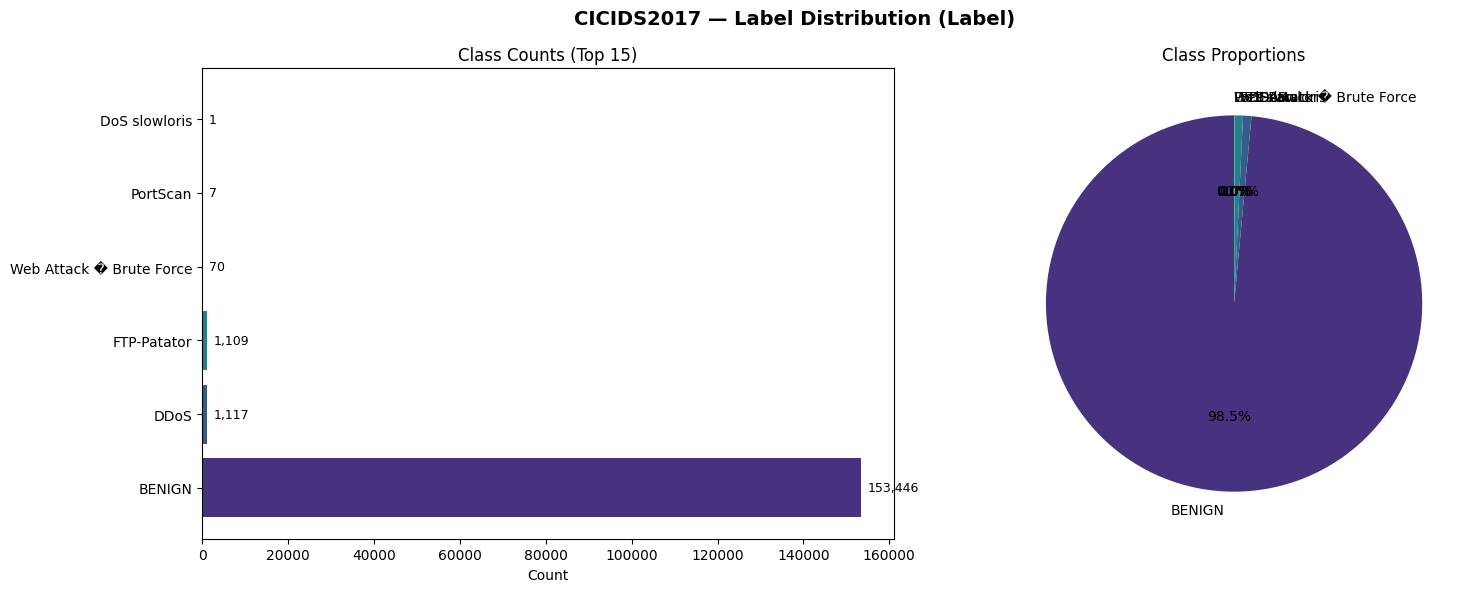


CICIDS2017 class counts:
Label
BENIGN                      153446
DDoS                          1117
FTP-Patator                   1109
Web Attack � Brute Force        70
PortScan                         7
DoS slowloris                    1
Name: count, dtype: int64


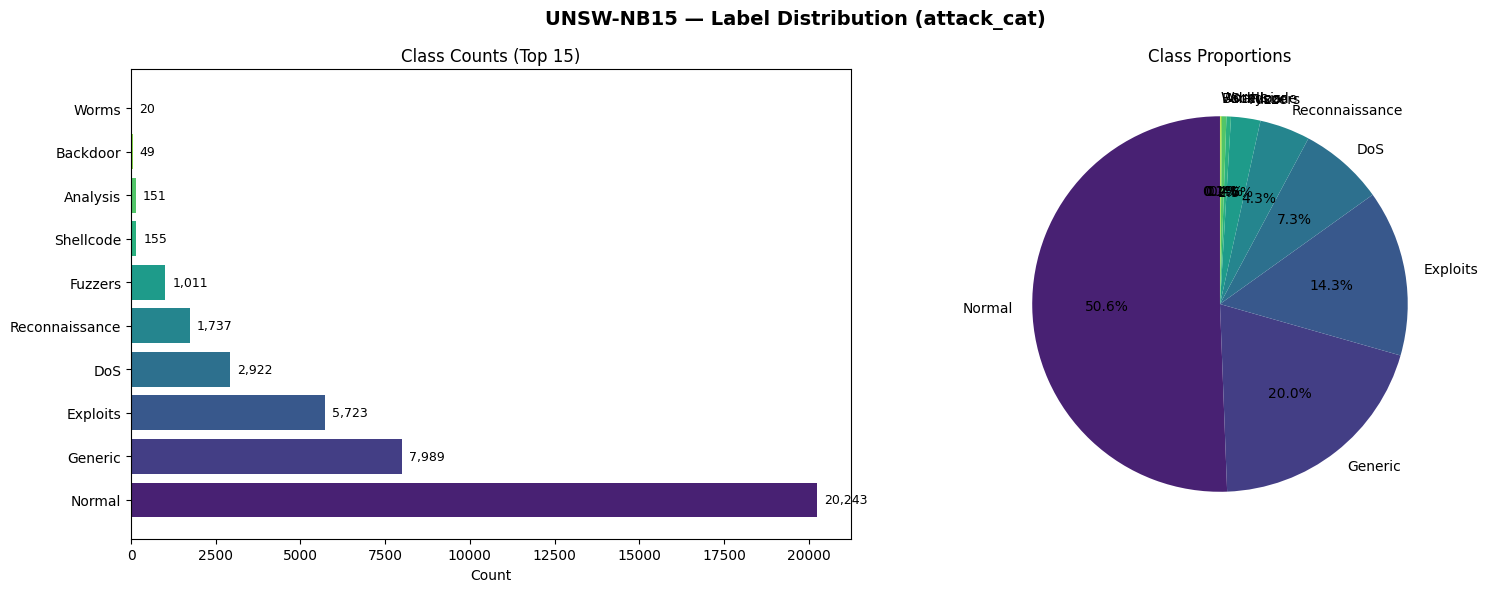


UNSW-NB15 class counts:
attack_cat
Normal            20243
Generic            7989
Exploits           5723
DoS                2922
Reconnaissance     1737
Fuzzers            1011
Shellcode           155
Analysis            151
Backdoor             49
Worms                20
Name: count, dtype: int64


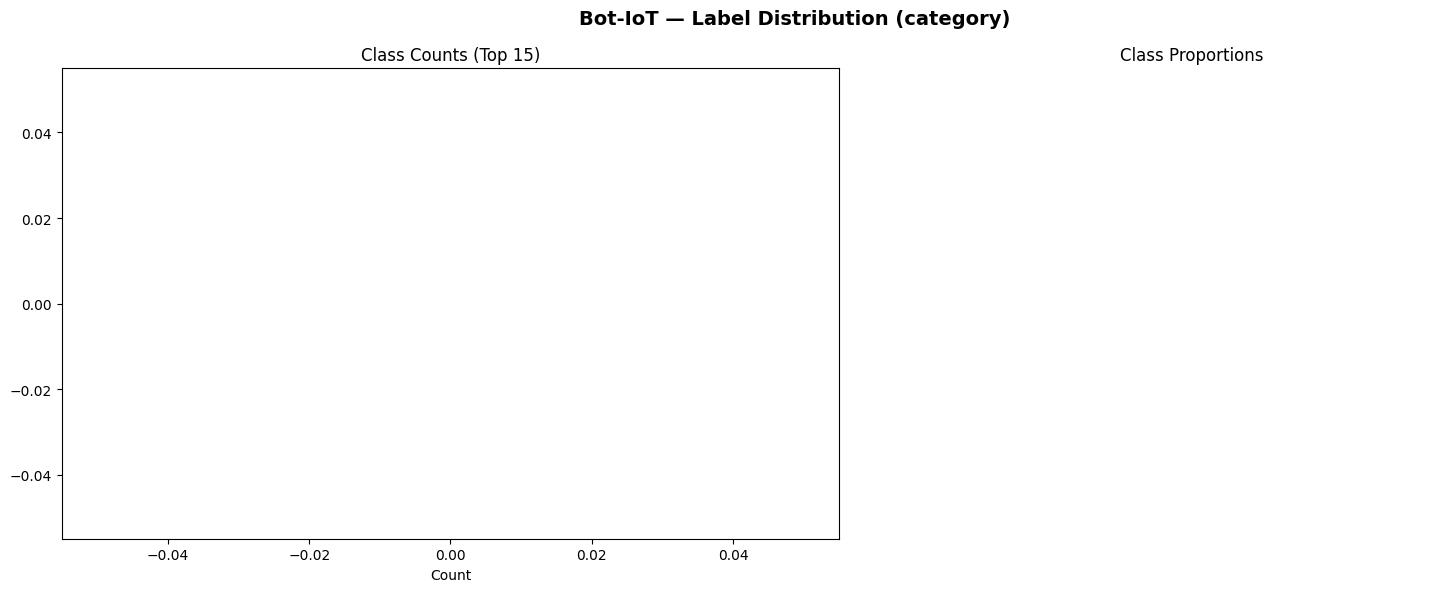


Bot-IoT class counts:
Series([], Name: count, dtype: int64)


In [17]:
def plot_label_distribution(df: pd.DataFrame, label_col: str, name: str, top_n: int = 15):
    """Plot class/label distribution."""
    if label_col not in df.columns:
        print(f'[WARNING] Column "{label_col}" not found in {name}')
        return
    
    counts = df[label_col].value_counts().head(top_n)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{name} — Label Distribution ({label_col})', fontsize=14, fontweight='bold')
    
    # Bar plot
    colors = sns.color_palette('viridis', len(counts))
    axes[0].barh(counts.index.astype(str), counts.values, color=colors)
    axes[0].set_xlabel('Count')
    axes[0].set_title('Class Counts (Top {})'.format(top_n))
    for i, v in enumerate(counts.values):
        axes[0].text(v + counts.values.max() * 0.01, i, f'{v:,}', va='center', fontsize=9)
    
    # Pie chart (log scale for readability)
    axes[1].pie(counts.values, labels=counts.index.astype(str), autopct='%1.1f%%',
                colors=colors, startangle=90)
    axes[1].set_title('Class Proportions')
    
    plt.tight_layout()
    plt.show()
    
    # Print counts
    print(f'\n{name} class counts:')
    print(df[label_col].value_counts())

# CICIDS2017 label column is typically 'Label'
if not df_cicids.empty:
    label_col_cicids = 'Label' if 'Label' in df_cicids.columns else df_cicids.columns[-1]
    plot_label_distribution(df_cicids, label_col_cicids, 'CICIDS2017')

# UNSW-NB15 label column: 'attack_cat' (multi-class) and 'label' (binary)
if not df_unsw.empty:
    label_col_unsw = 'attack_cat' if 'attack_cat' in df_unsw.columns else df_unsw.columns[-1]
    plot_label_distribution(df_unsw, label_col_unsw, 'UNSW-NB15')

# Bot-IoT label column: 'category' or 'attack'
if not df_botiot.empty:
    label_col_botiot = 'category' if 'category' in df_botiot.columns else (
        'attack' if 'attack' in df_botiot.columns else df_botiot.columns[-1]
    )
    plot_label_distribution(df_botiot, label_col_botiot, 'Bot-IoT')

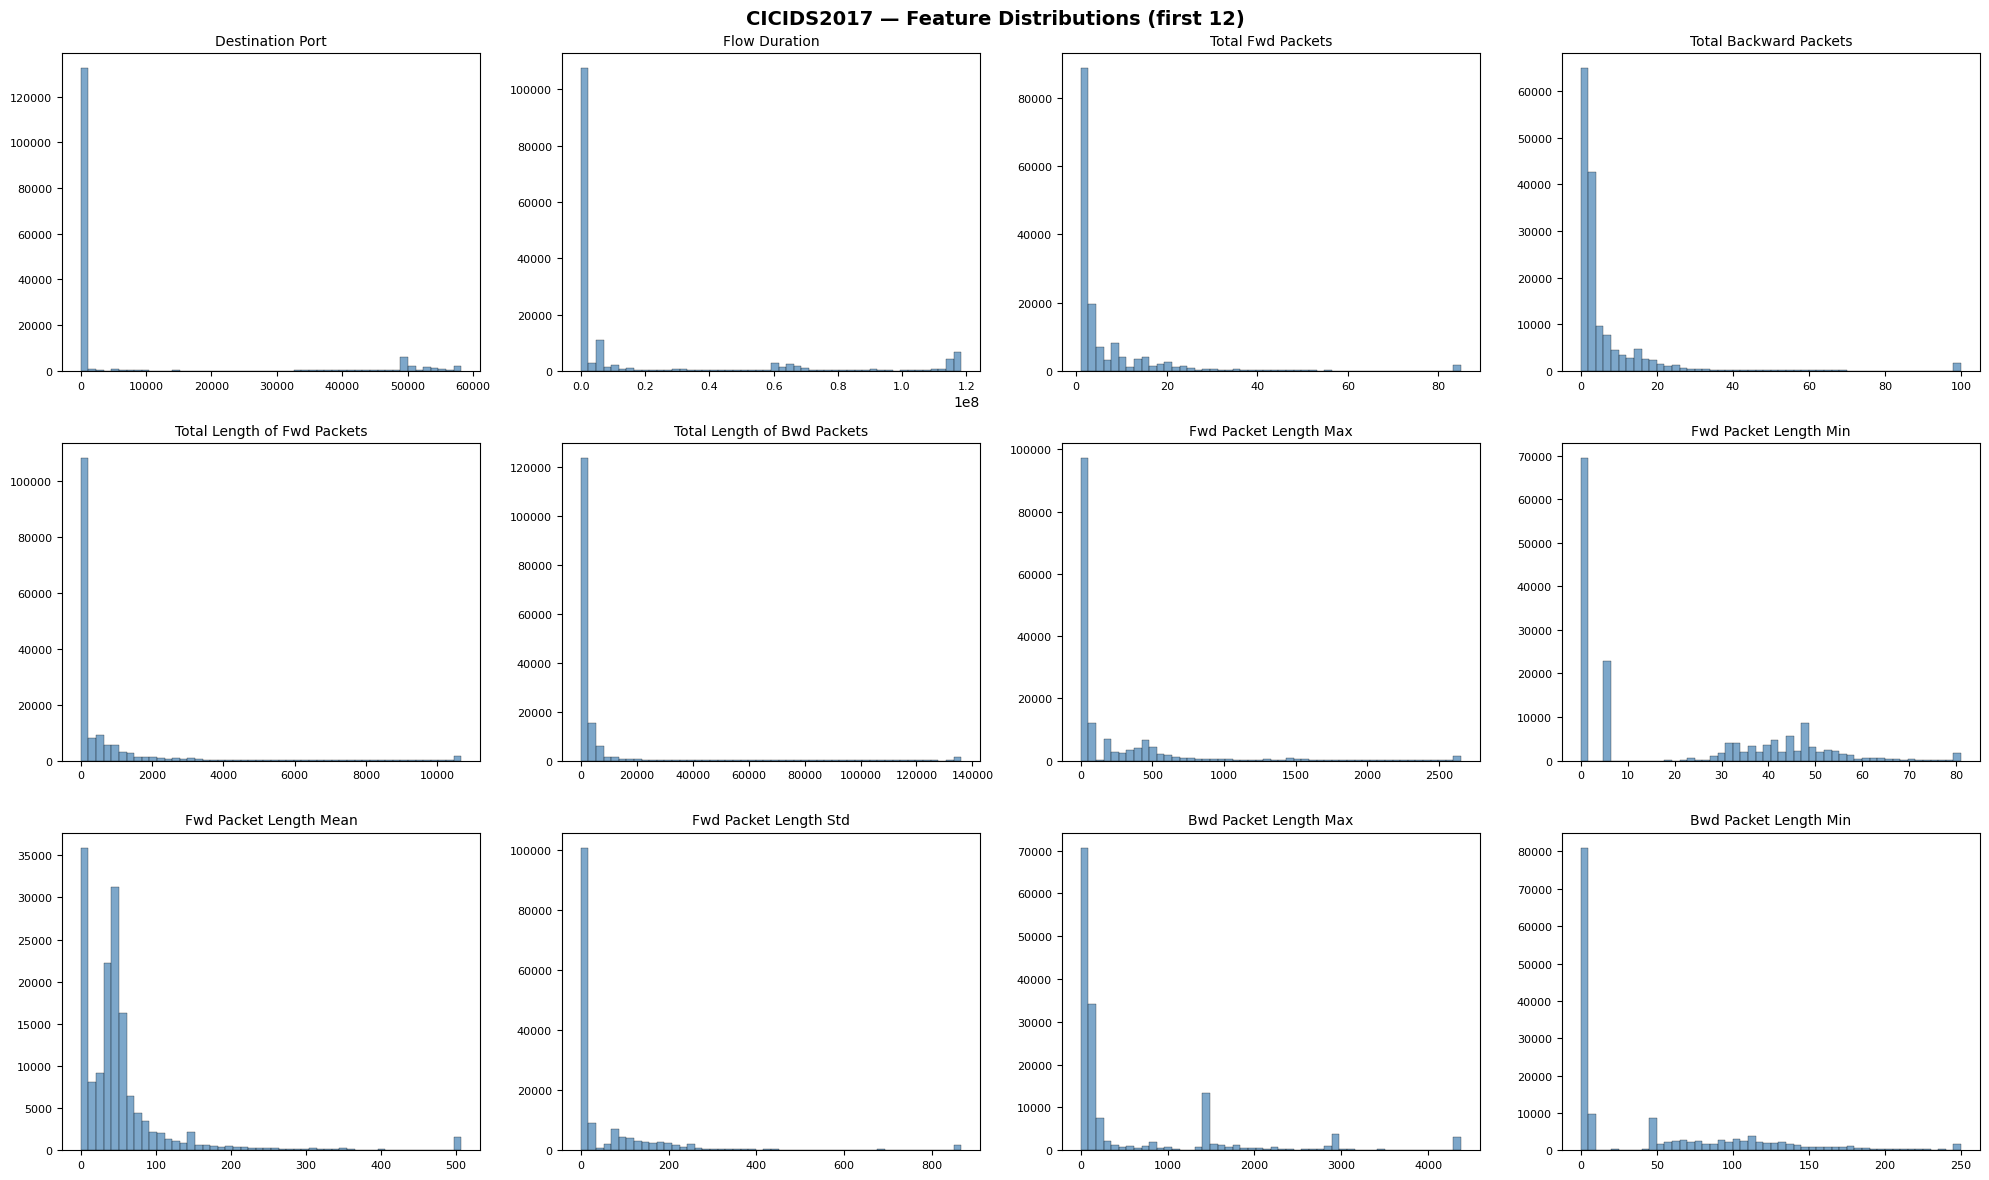

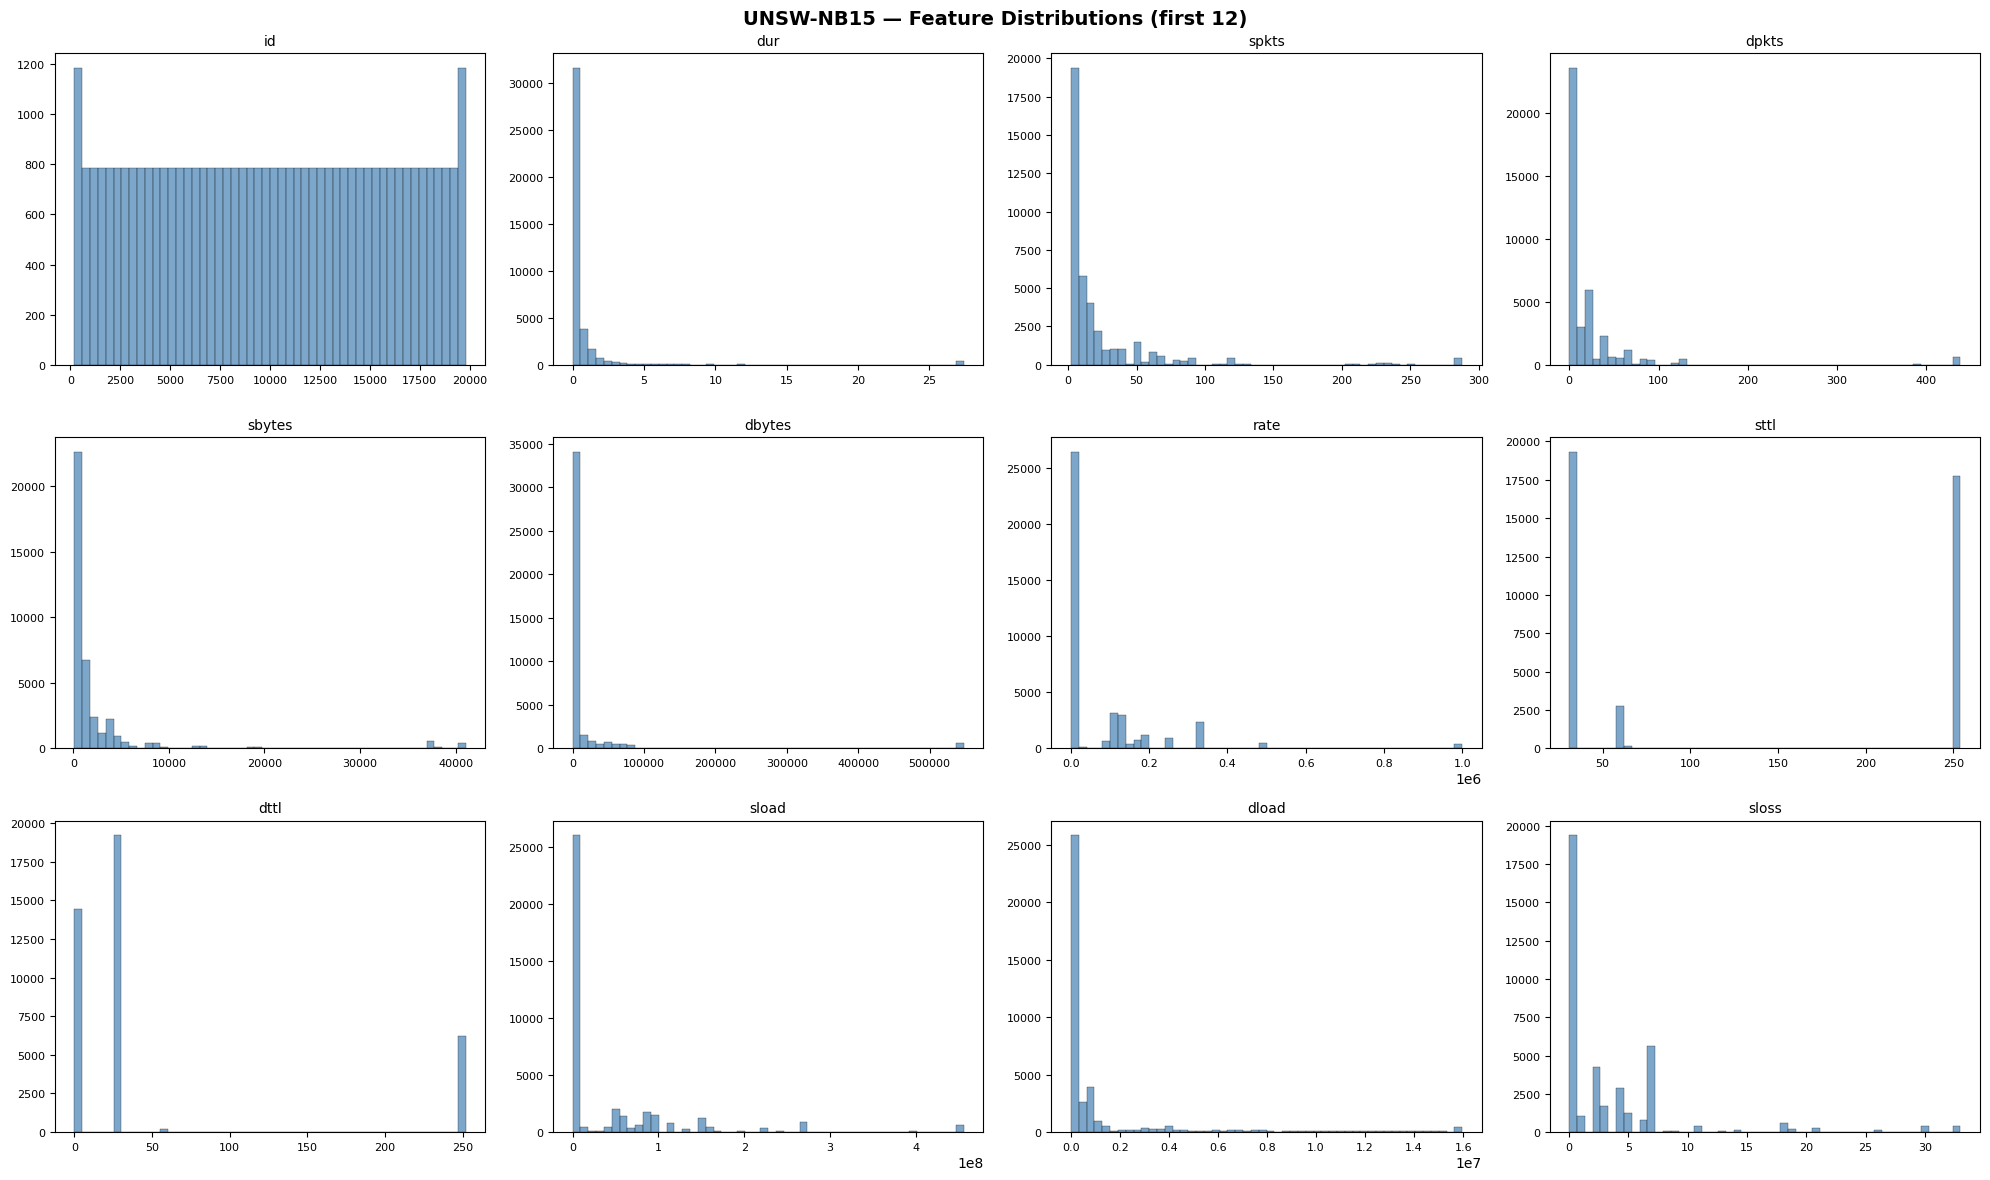

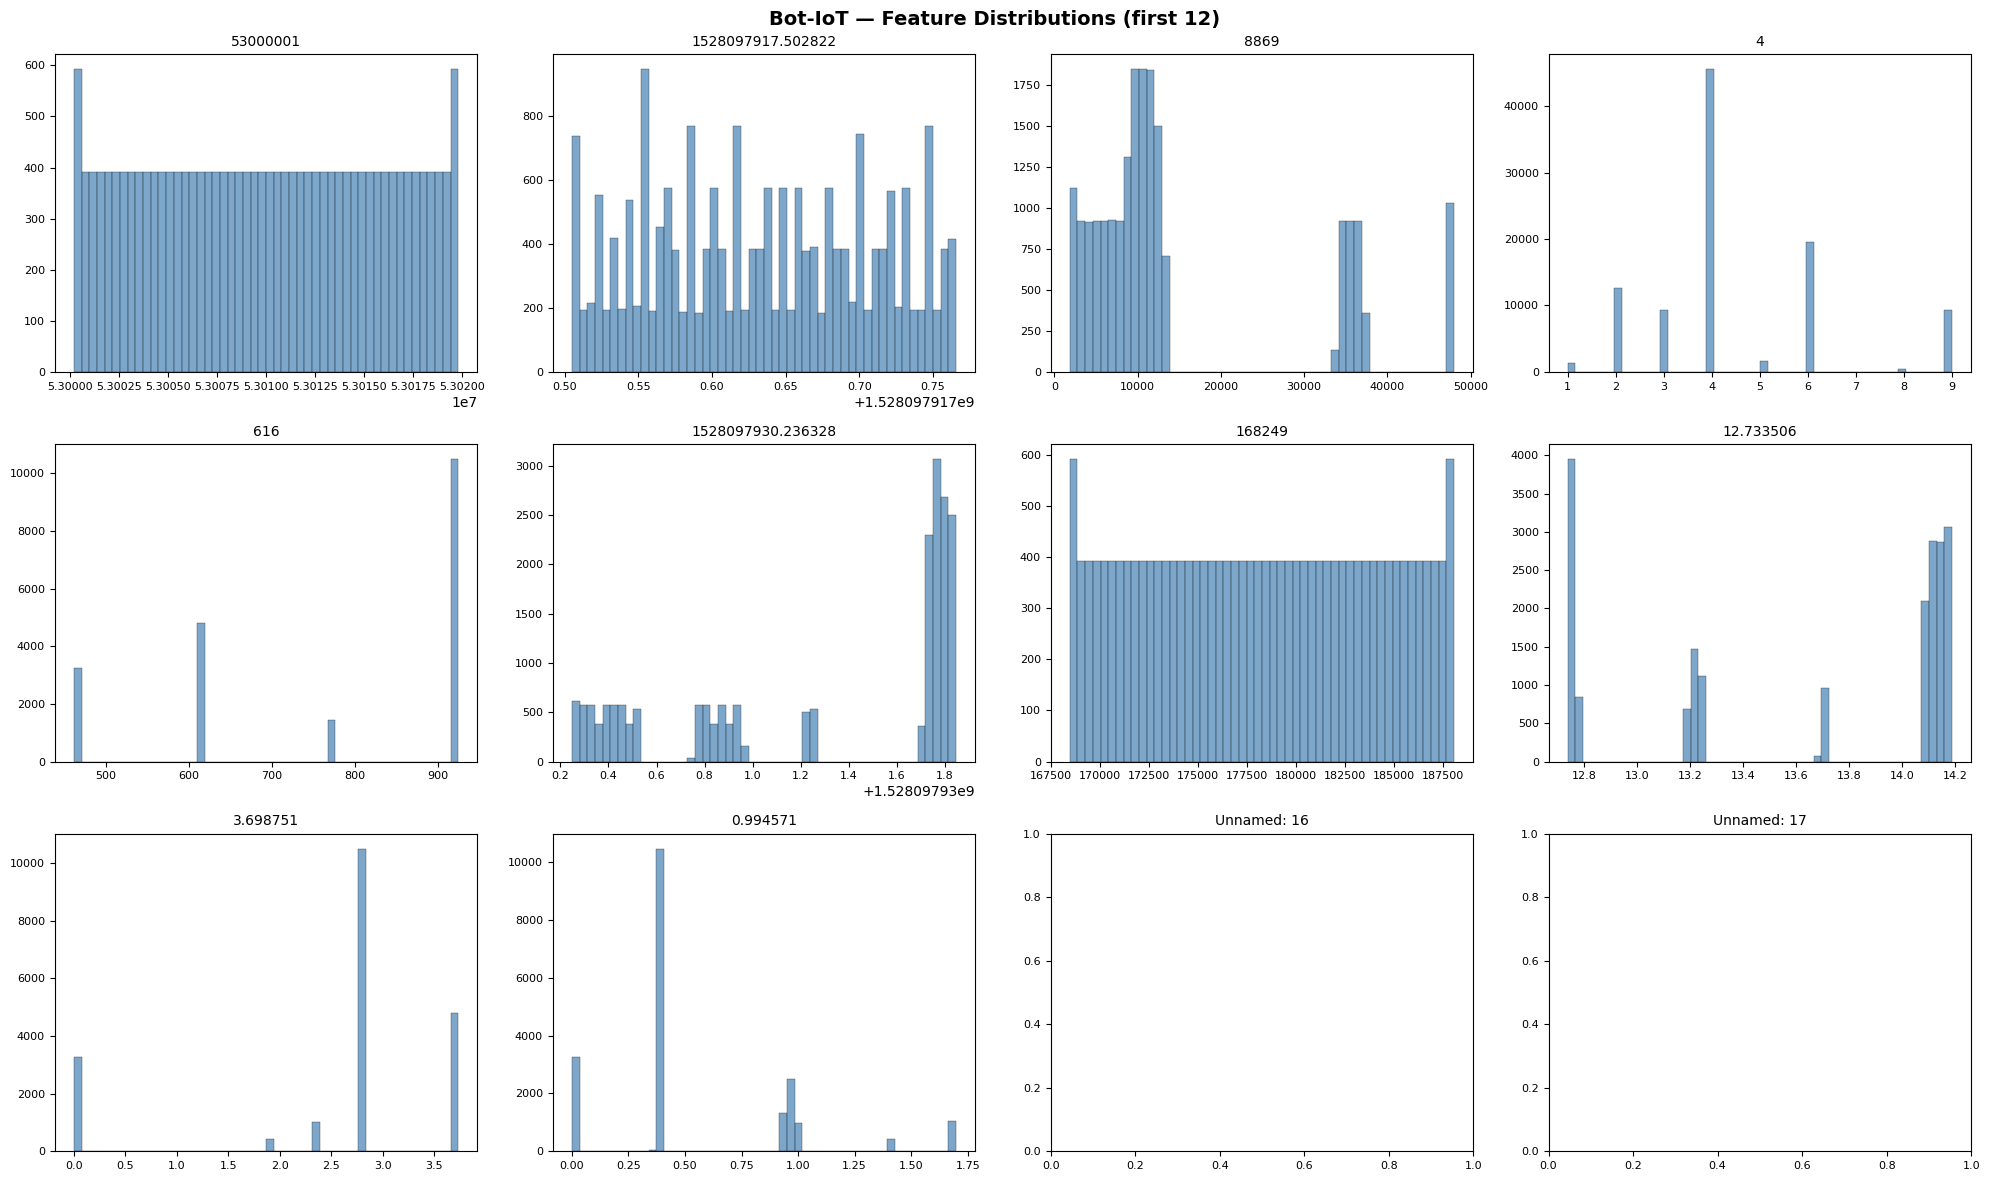

In [18]:
def plot_feature_distributions(df: pd.DataFrame, name: str, n_features: int = 12):
    """Plot distributions of numeric features."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) == 0:
        print(f'No numeric columns in {name}')
        return
    
    # Select a subset to plot
    cols_to_plot = numeric_cols[:n_features]
    n_rows = (len(cols_to_plot) + 3) // 4
    
    fig, axes = plt.subplots(n_rows, 4, figsize=(20, 4 * n_rows))
    fig.suptitle(f'{name} — Feature Distributions (first {n_features})', fontsize=14, fontweight='bold')
    axes = axes.flatten()
    
    for i, col in enumerate(cols_to_plot):
        data = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        if data.nunique() > 1:
            axes[i].hist(data.clip(data.quantile(0.01), data.quantile(0.99)),
                        bins=50, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.3)
        axes[i].set_title(col, fontsize=10)
        axes[i].tick_params(labelsize=8)
    
    # Hide empty subplots
    for j in range(len(cols_to_plot), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

for df, name in [(df_cicids, 'CICIDS2017'), (df_unsw, 'UNSW-NB15'), (df_botiot, 'Bot-IoT')]:
    if not df.empty:
        plot_feature_distributions(df, name)

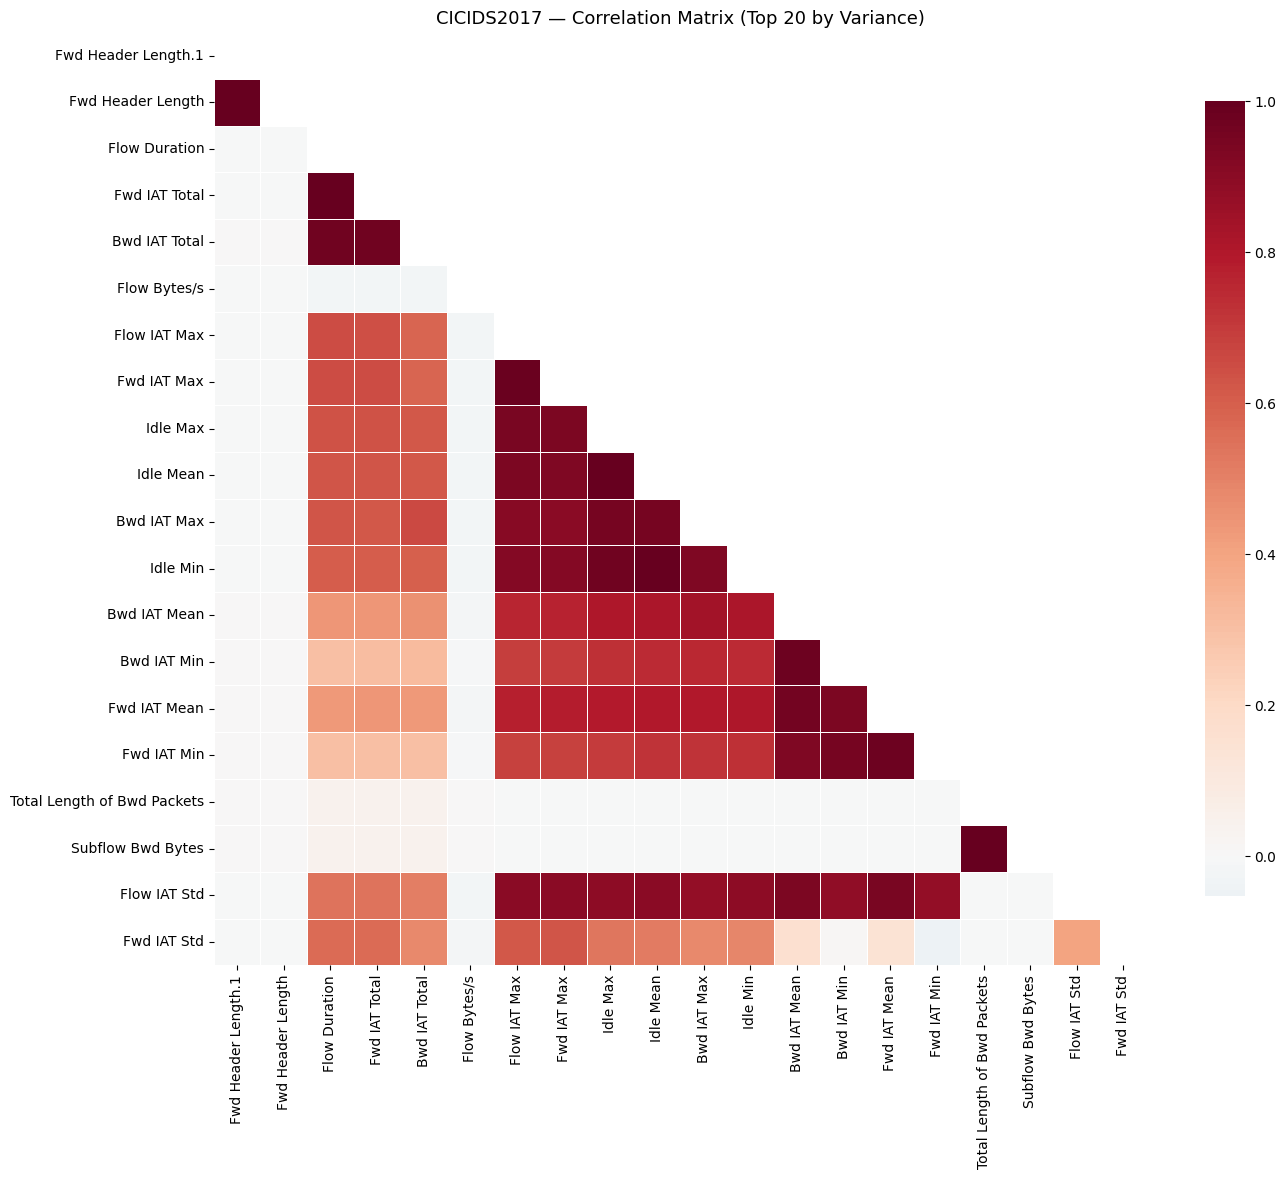

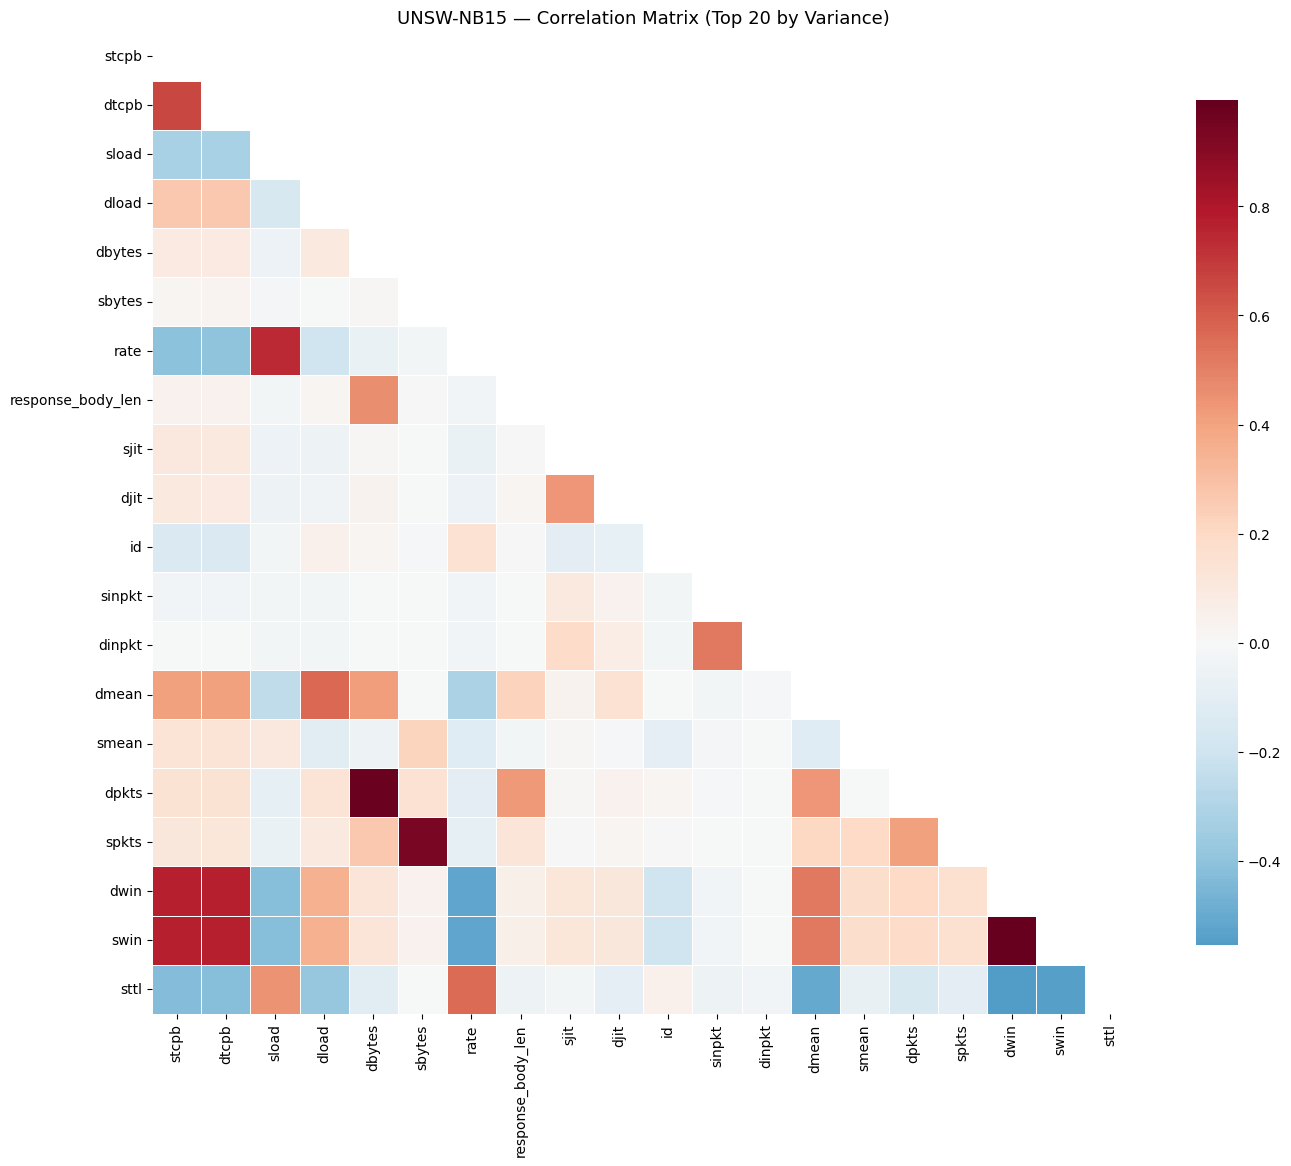

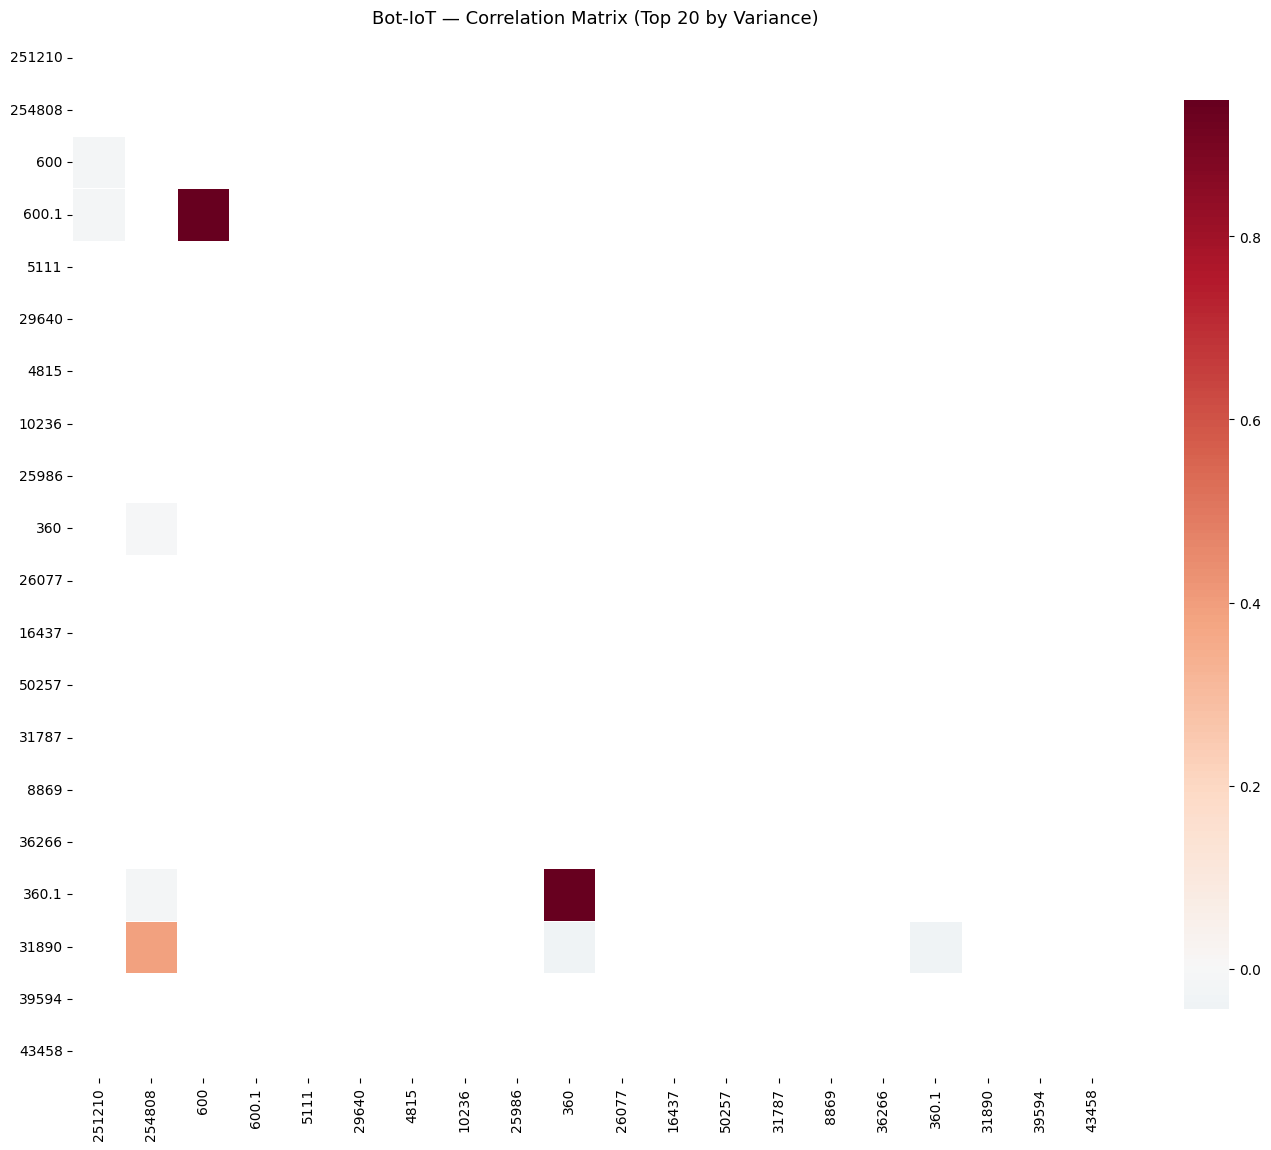

In [19]:
def plot_correlation_matrix(df: pd.DataFrame, name: str, top_n: int = 20):
    """Plot correlation matrix for top N numeric features (by variance)."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df_num = df[numeric_cols].replace([np.inf, -np.inf], np.nan).dropna(axis=1, how='all')
    
    # Select top N by variance
    variances = df_num.var().sort_values(ascending=False)
    top_cols = variances.head(top_n).index.tolist()
    
    corr = df_num[top_cols].corr()
    
    fig, ax = plt.subplots(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=False,
                square=True, linewidths=0.5, ax=ax,
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'{name} — Correlation Matrix (Top {top_n} by Variance)', fontsize=13)
    plt.tight_layout()
    plt.show()

for df, name in [(df_cicids, 'CICIDS2017'), (df_unsw, 'UNSW-NB15'), (df_botiot, 'Bot-IoT')]:
    if not df.empty:
        plot_correlation_matrix(df, name)

---
## 6. Data Cleaning Pipeline

Common issues across all datasets:
- Missing values (NaN)
- Infinite values (±inf)
- Duplicate rows
- Inconsistent column naming
- Non-numeric entries in numeric columns

In [20]:
class DataCleaner:
    """
    Unified data cleaning pipeline for network intrusion datasets.
    Handles: column normalization, inf/nan removal, dtype fixes,
    duplicate removal, and label standardization.
    """
    
    def __init__(self, verbose: bool = True):
        self.verbose = verbose
        self.cleaning_log = []
    
    def _log(self, msg: str):
        self.cleaning_log.append(msg)
        if self.verbose:
            print(f'  [CLEAN] {msg}')
    
    def normalize_columns(self, df: pd.DataFrame) -> pd.DataFrame:
        """Standardize column names: lowercase, strip, replace spaces."""
        original_cols = list(df.columns)
        df.columns = (
            df.columns
            .str.strip()
            .str.lower()
            .str.replace(' ', '_', regex=False)
            .str.replace('/', '_', regex=False)
            .str.replace('-', '_', regex=False)
        )
        changed = sum(1 for a, b in zip(original_cols, df.columns) if a != b)
        self._log(f'Normalized {changed} column names')
        return df
    
    def remove_duplicates(self, df: pd.DataFrame) -> pd.DataFrame:
        """Remove duplicate rows."""
        n_before = len(df)
        df = df.drop_duplicates().reset_index(drop=True)
        n_removed = n_before - len(df)
        self._log(f'Removed {n_removed:,} duplicate rows ({n_removed/max(n_before,1)*100:.1f}%)')
        return df
    
    def handle_infinity(self, df: pd.DataFrame) -> pd.DataFrame:
        """Replace inf/-inf with NaN, then impute."""
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        inf_count = np.isinf(df[numeric_cols]).sum().sum()
        df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
        self._log(f'Replaced {inf_count:,} infinite values with NaN')
        return df
    
    def handle_missing(self, df: pd.DataFrame, strategy: str = 'median') -> pd.DataFrame:
        """Handle missing values in numeric columns."""
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        n_missing_before = df[numeric_cols].isnull().sum().sum()
        
        if strategy == 'median':
            df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
        elif strategy == 'mean':
            df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
        elif strategy == 'zero':
            df[numeric_cols] = df[numeric_cols].fillna(0)
        elif strategy == 'drop':
            df = df.dropna(subset=numeric_cols).reset_index(drop=True)
        
        # Handle categorical missing values
        cat_cols = df.select_dtypes(include=['object', 'category']).columns
        for col in cat_cols:
            df[col] = df[col].fillna('unknown')
        
        n_missing_after = df.isnull().sum().sum()
        self._log(f'Missing values: {n_missing_before:,} → {n_missing_after:,} (strategy={strategy})')
        return df
    
    def fix_dtypes(self, df: pd.DataFrame) -> pd.DataFrame:
        """Convert columns to appropriate dtypes to save memory."""
        mem_before = df.memory_usage(deep=True).sum() / 1e6
        
        # Downcast numeric columns
        for col in df.select_dtypes(include=['float64']).columns:
            df[col] = pd.to_numeric(df[col], downcast='float')
        for col in df.select_dtypes(include=['int64']).columns:
            df[col] = pd.to_numeric(df[col], downcast='integer')
        
        mem_after = df.memory_usage(deep=True).sum() / 1e6
        self._log(f'Memory: {mem_before:.1f} MB → {mem_after:.1f} MB ({(1 - mem_after/mem_before)*100:.1f}% reduction)')
        return df
    
    def remove_constant_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Remove columns with zero variance (constant)."""
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        n_before = len(numeric_cols)
        constant_cols = [col for col in numeric_cols if df[col].nunique() <= 1]
        if constant_cols:
            df = df.drop(columns=constant_cols)
        self._log(f'Removed {len(constant_cols)} constant features: {constant_cols}')
        return df
    
    def clean(self, df: pd.DataFrame, name: str = 'dataset') -> pd.DataFrame:
        """Run the full cleaning pipeline."""
        print(f'\n{"="*50}')
        print(f'  Cleaning: {name}')
        print(f'  Input shape: {df.shape}')
        print(f'{"="*50}')
        
        df = self.normalize_columns(df)
        df = self.remove_duplicates(df)
        df = self.handle_infinity(df)
        df = self.handle_missing(df, strategy='median')
        df = self.remove_constant_features(df)
        df = self.fix_dtypes(df)
        
        print(f'  Output shape: {df.shape}')
        return df

# Initialize cleaner
cleaner = DataCleaner(verbose=True)

# Clean each dataset
if not df_cicids.empty:
    df_cicids = cleaner.clean(df_cicids, 'CICIDS2017')

if not df_unsw.empty:
    df_unsw = cleaner.clean(df_unsw, 'UNSW-NB15')

if not df_botiot.empty:
    df_botiot = cleaner.clean(df_botiot, 'Bot-IoT')


  Cleaning: CICIDS2017
  Input shape: (155750, 79)
  [CLEAN] Normalized 77 column names
  [CLEAN] Removed 0 duplicate rows (0.0%)
  [CLEAN] Replaced 0 infinite values with NaN
  [CLEAN] Missing values: 0 → 0 (strategy=median)
  [CLEAN] Removed 10 constant features: ['bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'cwe_flag_count', 'fwd_avg_bytes_bulk', 'fwd_avg_packets_bulk', 'fwd_avg_bulk_rate', 'bwd_avg_bytes_bulk', 'bwd_avg_packets_bulk', 'bwd_avg_bulk_rate']
  [CLEAN] Memory: 93.3 MB → 55.5 MB (40.6% reduction)
  Output shape: (155750, 69)

  Cleaning: UNSW-NB15
  Input shape: (40000, 45)
  [CLEAN] Normalized 0 column names
  [CLEAN] Removed 0 duplicate rows (0.0%)
  [CLEAN] Replaced 0 infinite values with NaN
  [CLEAN] Missing values: 0 → 0 (strategy=median)
  [CLEAN] Removed 0 constant features: []
  [CLEAN] Memory: 21.6 MB → 13.6 MB (36.9% reduction)
  Output shape: (40000, 45)

  Cleaning: Bot-IoT
  Input shape: (420000, 368)
  [CLEAN] Normalized 13 column names
  [CLEAN] R

---
## 7. Label Standardization

Create unified binary and multi-class labels across all datasets:
- **Binary**: `0 = Benign`, `1 = Attack`
- **Multi-class**: Unified attack categories (DDoS, DoS, Brute Force, Botnet, Port Scan, Injection, Other)

In [21]:
# ============================================================
# CICIDS2017 Label Mapping
# ============================================================
CICIDS_LABEL_MAP = {
    'BENIGN': 'Benign',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'Heartbleed': 'DoS',
    'PortScan': 'PortScan',
    'FTP-Patator': 'BruteForce',
    'SSH-Patator': 'BruteForce',
    'Bot': 'Botnet',
    'Web Attack \x96 Brute Force': 'BruteForce',
    'Web Attack \x96 XSS': 'Injection',
    'Web Attack \x96 Sql Injection': 'Injection',
    'Infiltration': 'Other',
}

# ============================================================
# UNSW-NB15 Label Mapping
# ============================================================
UNSW_LABEL_MAP = {
    'Normal': 'Benign',
    'Fuzzers': 'Other',
    'Analysis': 'Other',
    'Backdoor': 'Other',
    'Backdoors': 'Other',
    'DoS': 'DoS',
    'Exploits': 'Injection',
    'Generic': 'Other',
    'Reconnaissance': 'PortScan',
    'Shellcode': 'Injection',
    'Worms': 'Other',
}

# ============================================================
# Bot-IoT Label Mapping
# ============================================================
BOTIOT_LABEL_MAP = {
    'Normal': 'Benign',
    'DDoS': 'DDoS',
    'DoS': 'DoS',
    'Reconnaissance': 'PortScan',
    'Theft': 'Other',
}


def standardize_labels(df: pd.DataFrame, label_col: str, label_map: dict, name: str) -> pd.DataFrame:
    """
    Standardize labels using a mapping dictionary.
    Creates: 'attack_category' (multi-class) and 'is_attack' (binary).
    """
    if label_col not in df.columns:
        print(f'[WARNING] Column "{label_col}" not in {name}. Available: {list(df.columns[-5:])}')
        return df
    
    # Map labels
    original_labels = df[label_col].str.strip().unique()
    df['attack_category'] = df[label_col].str.strip().map(label_map).fillna('Other')
    
    # Binary label
    df['is_attack'] = (df['attack_category'] != 'Benign').astype(int)
    
    # Report unmapped labels
    mapped_labels = set(label_map.keys())
    unmapped = set(original_labels) - mapped_labels
    if unmapped:
        print(f'  [INFO] Unmapped labels in {name} (mapped to Other): {unmapped}')
    
    print(f'\n{name} — Standardized Labels:')
    print(f'  Binary: {df["is_attack"].value_counts().to_dict()}')
    print(f'  Multi-class: {df["attack_category"].value_counts().to_dict()}')
    
    return df

# Apply label standardization
if not df_cicids.empty:
    label_col = 'label' if 'label' in df_cicids.columns else 'Label'
    # After column normalization it's lowercase
    if 'label' in df_cicids.columns:
        df_cicids = standardize_labels(df_cicids, 'label', CICIDS_LABEL_MAP, 'CICIDS2017')

if not df_unsw.empty:
    label_col = 'attack_cat' if 'attack_cat' in df_unsw.columns else 'attack_category'
    if label_col in df_unsw.columns:
        df_unsw = standardize_labels(df_unsw, label_col, UNSW_LABEL_MAP, 'UNSW-NB15')

if not df_botiot.empty:
    label_col = 'category' if 'category' in df_botiot.columns else 'attack'
    if label_col in df_botiot.columns:
        df_botiot = standardize_labels(df_botiot, label_col, BOTIOT_LABEL_MAP, 'Bot-IoT')

  [INFO] Unmapped labels in CICIDS2017 (mapped to Other): {'Web Attack � Brute Force'}

CICIDS2017 — Standardized Labels:
  Binary: {0: 153446, 1: 2304}
  Multi-class: {'Benign': 153446, 'DDoS': 1117, 'BruteForce': 1109, 'Other': 70, 'PortScan': 7, 'DoS': 1}

UNSW-NB15 — Standardized Labels:
  Binary: {0: 20243, 1: 19757}
  Multi-class: {'Benign': 20243, 'Other': 9220, 'Injection': 5878, 'DoS': 2922, 'PortScan': 1737}
  [INFO] Unmapped labels in Bot-IoT (mapped to Other): {'unknown'}

Bot-IoT — Standardized Labels:
  Binary: {1: 420000}
  Multi-class: {'Other': 420000}


---
## 8. Feature Engineering

In [22]:
class FeatureEngineer:
    """
    Feature engineering pipeline:
    - Encode categoricals (Label Encoding for tree models, one-hot for DL)
    - Scale numeric features
    - Select top-K features by mutual information
    - Remove highly correlated features
    """
    
    def __init__(self, target_binary: str = 'is_attack', target_multi: str = 'attack_category'):
        self.target_binary = target_binary
        self.target_multi = target_multi
        self.label_encoders = {}
        self.scaler = None
        self.selected_features = None
        self.feature_importance = None
    
    def encode_categoricals(self, df: pd.DataFrame) -> pd.DataFrame:
        """Label-encode categorical features (excluding target columns)."""
        cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
        exclude = [self.target_binary, self.target_multi]
        cat_cols = [c for c in cat_cols if c not in exclude]
        
        for col in cat_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            self.label_encoders[col] = le
            print(f'  Encoded "{col}": {len(le.classes_)} classes')
        
        return df
    
    def remove_highly_correlated(self, df: pd.DataFrame, threshold: float = 0.95) -> pd.DataFrame:
        """Remove features with correlation > threshold."""
        exclude = [self.target_binary, self.target_multi]
        numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
        
        corr_matrix = df[numeric_cols].corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
        
        if to_drop:
            df = df.drop(columns=to_drop)
            print(f'  Removed {len(to_drop)} highly correlated features (r > {threshold})')
        
        return df
    
    def select_features_mi(self, df: pd.DataFrame, k: int = 50) -> pd.DataFrame:
        """Select top-K features using mutual information."""
        exclude = [self.target_binary, self.target_multi]
        feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
        
        if len(feature_cols) <= k:
            print(f'  Feature selection: {len(feature_cols)} features ≤ k={k}, keeping all.')
            self.selected_features = feature_cols
            return df
        
        X = df[feature_cols].values
        y = df[self.target_binary].values
        
        # Mutual Information
        mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE, n_neighbors=5)
        mi_df = pd.DataFrame({'feature': feature_cols, 'mi_score': mi_scores})
        mi_df = mi_df.sort_values('mi_score', ascending=False)
        
        self.feature_importance = mi_df
        top_features = mi_df.head(k)['feature'].tolist()
        self.selected_features = top_features
        
        print(f'  Selected top {k} features by Mutual Information')
        print(f'  Top 10: {top_features[:10]}')
        
        # Plot MI scores
        fig, ax = plt.subplots(figsize=(12, 6))
        top_20 = mi_df.head(20)
        ax.barh(top_20['feature'], top_20['mi_score'], color='teal')
        ax.set_xlabel('Mutual Information Score')
        ax.set_title('Top 20 Features by Mutual Information')
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()
        
        keep_cols = top_features + [c for c in exclude if c in df.columns]
        return df[keep_cols]
    
    def scale_features(self, df: pd.DataFrame, method: str = 'robust') -> pd.DataFrame:
        """Scale numeric features using the specified method."""
        exclude = [self.target_binary, self.target_multi]
        feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
        
        if method == 'standard':
            self.scaler = StandardScaler()
        elif method == 'minmax':
            self.scaler = MinMaxScaler()
        elif method == 'robust':
            self.scaler = RobustScaler()
        
        df[feature_cols] = self.scaler.fit_transform(df[feature_cols])
        print(f'  Scaled {len(feature_cols)} features using {method} scaler')
        return df
    
    def process(self, df: pd.DataFrame, name: str, k_features: int = 50) -> pd.DataFrame:
        """Full feature engineering pipeline."""
        print(f'\n{"="*50}')
        print(f'  Feature Engineering: {name}')
        print(f'{"="*50}')
        
        df = self.encode_categoricals(df)
        df = self.remove_highly_correlated(df, threshold=0.95)
        df = self.select_features_mi(df, k=k_features)
        df = self.scale_features(df, method='robust')
        
        print(f'  Final shape: {df.shape}')
        return df


  Feature Engineering: CICIDS2017
  Feature selection: 46 features ≤ k=50, keeping all.
  Scaled 46 features using robust scaler
  Final shape: (155750, 48)

  Feature Engineering: UNSW-NB15
  Feature selection: 35 features ≤ k=40, keeping all.
  Scaled 35 features using robust scaler
  Final shape: (40000, 37)

  Feature Engineering: Bot-IoT
  Encoded "tcp": 3 classes
  Encoded "192.168.100.149": 7 classes
  Encoded "192.168.100.7": 9 classes
  Encoded "80": 10 classes
  Encoded "req": 4 classes
  Encoded "ddos": 2 classes
  Encoded "192.168.100.147": 6 classes
  Encoded "e": 4 classes
  Encoded "udp": 5 classes
  Encoded "447": 20001 classes
  Encoded "192.168.100.3": 5 classes
  Encoded "int": 4 classes
  Encoded "192.168.100.148": 10 classes
  Encoded "29364": 16716 classes
  Encoded "192.168.100.150": 11 classes
  Encoded "31826": 16920 classes
  Encoded "192.168.100.5": 4 classes
  Encoded "192.168.100.6": 2 classes
  Encoded "47869": 17439 classes
  Encoded "pkseqid": 1 classes

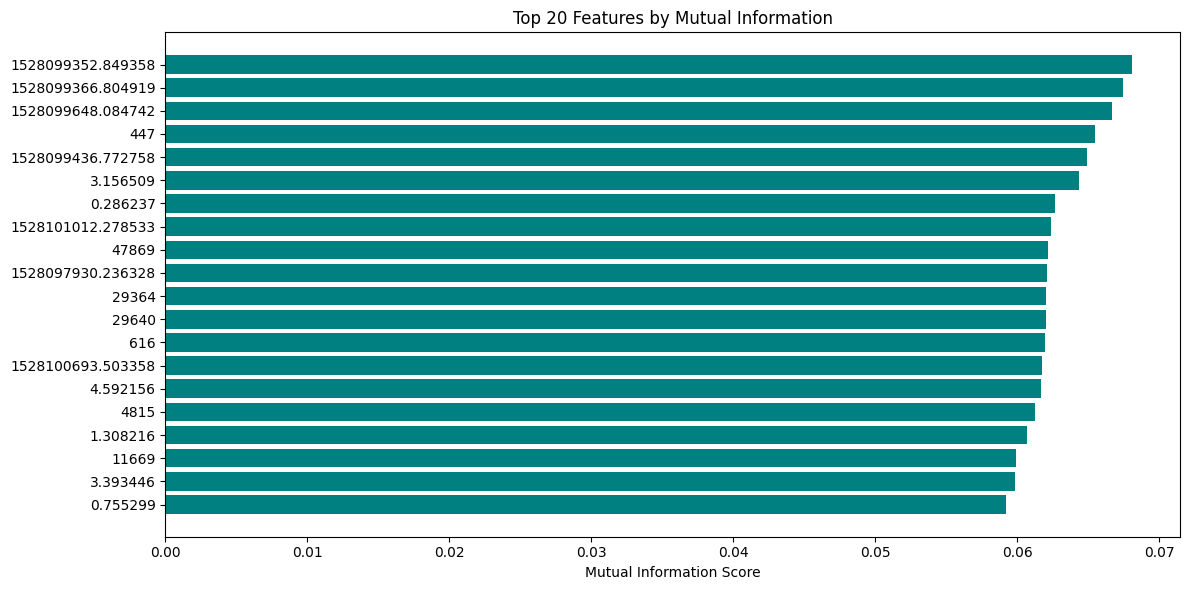

  Scaled 30 features using robust scaler
  Final shape: (420000, 32)


In [25]:
# Process each dataset
fe_cicids = FeatureEngineer()
fe_unsw = FeatureEngineer()
fe_botiot = FeatureEngineer()

if not df_cicids.empty:
    df_cicids = fe_cicids.process(df_cicids, 'CICIDS2017', k_features=50)

if not df_unsw.empty:
    df_unsw = fe_unsw.process(df_unsw, 'UNSW-NB15', k_features=40)

if not df_botiot.empty:
    df_botiot = fe_botiot.process(df_botiot, 'Bot-IoT', k_features=30)

In [26]:
# Fix for potential duplicate columns which causes LabelEncoder to fail
def remove_duplicate_columns(df: pd.DataFrame, name: str) -> pd.DataFrame:
    if df.columns.duplicated().any():
        n_dupes = df.columns.duplicated().sum()
        print(f"[{name}] Found {n_dupes} duplicate columns. Removing duplicates (keeping first).")
        df = df.loc[:, ~df.columns.duplicated()]
    return df

df_cicids = remove_duplicate_columns(df_cicids, "CICIDS2017")
df_unsw = remove_duplicate_columns(df_unsw, "UNSW-NB15")
df_botiot = remove_duplicate_columns(df_botiot, "Bot-IoT")

---
## 9. Class Balancing

Network intrusion datasets are heavily imbalanced. We use a combination of:
- **Undersampling** majority class
- **SMOTE** (Synthetic Minority Oversampling) — saved for model training notebooks
- Here we do **controlled undersampling** to avoid memory issues

In [27]:
def balance_dataset(df: pd.DataFrame, target_col: str = 'is_attack',
                    max_samples_per_class: int = 100_000,
                    min_samples_per_class: int = 1000) -> pd.DataFrame:
    """
    Balance the dataset by capping majority classes and keeping minority classes.
    More sophisticated balancing (SMOTE) is done in training notebooks.
    """
    print(f'\nBalancing dataset (target: {target_col})...')
    print(f'  Before: {df[target_col].value_counts().to_dict()}')
    
    balanced_parts = []
    for cls in df[target_col].unique():
        cls_df = df[df[target_col] == cls]
        n = len(cls_df)
        
        if n > max_samples_per_class:
            cls_df = cls_df.sample(n=max_samples_per_class, random_state=RANDOM_STATE)
        elif n < min_samples_per_class:
            # Upsample very small classes
            cls_df = resample(cls_df, replace=True, n_samples=min_samples_per_class,
                            random_state=RANDOM_STATE)
        
        balanced_parts.append(cls_df)
    
    df_balanced = pd.concat(balanced_parts, ignore_index=True)
    df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    
    print(f'  After:  {df_balanced[target_col].value_counts().to_dict()}')
    print(f'  Shape:  {df_balanced.shape}')
    return df_balanced

# Balance for binary classification
if not df_cicids.empty:
    df_cicids_balanced = balance_dataset(df_cicids, 'is_attack', max_samples_per_class=100_000)
else:
    df_cicids_balanced = pd.DataFrame()

if not df_unsw.empty:
    df_unsw_balanced = balance_dataset(df_unsw, 'is_attack', max_samples_per_class=80_000)
else:
    df_unsw_balanced = pd.DataFrame()

if not df_botiot.empty:
    df_botiot_balanced = balance_dataset(df_botiot, 'is_attack', max_samples_per_class=50_000)
else:
    df_botiot_balanced = pd.DataFrame()


Balancing dataset (target: is_attack)...
  Before: {0: 153446, 1: 2304}
  After:  {0: 100000, 1: 2304}
  Shape:  (102304, 48)

Balancing dataset (target: is_attack)...
  Before: {0: 20243, 1: 19757}
  After:  {0: 20243, 1: 19757}
  Shape:  (40000, 37)

Balancing dataset (target: is_attack)...
  Before: {1: 420000}
  After:  {1: 50000}
  Shape:  (50000, 32)


---
## 10. Train / Validation / Test Split

Strategy: **70% Train / 15% Validation / 15% Test** with stratification.

In [28]:
def split_dataset(df: pd.DataFrame, target_col: str = 'is_attack',
                  test_size: float = 0.15, val_size: float = 0.15,
                  random_state: int = 42) -> dict:
    """
    Split dataset into train/val/test with stratification.
    Returns dict with keys: X_train, X_val, X_test, y_train, y_val, y_test
    Also includes multi-class labels if 'attack_category' exists.
    """
    exclude_cols = ['is_attack', 'attack_category']
    feature_cols = [c for c in df.columns if c not in exclude_cols]
    
    X = df[feature_cols].values.astype(np.float32)
    y_binary = df[target_col].values.astype(np.int64)
    
    # Check if multi-class labels exist
    y_multi = None
    multi_le = None
    if 'attack_category' in df.columns:
        multi_le = LabelEncoder()
        y_multi = multi_le.fit_transform(df['attack_category'].values)
    
    # First split: train+val vs test
    X_trainval, X_test, y_bin_trainval, y_bin_test = train_test_split(
        X, y_binary, test_size=test_size, random_state=random_state, stratify=y_binary
    )
    
    # Second split: train vs val
    val_fraction = val_size / (1 - test_size)
    X_train, X_val, y_bin_train, y_bin_val = train_test_split(
        X_trainval, y_bin_trainval, test_size=val_fraction,
        random_state=random_state, stratify=y_bin_trainval
    )
    
    result = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train_binary': y_bin_train, 'y_val_binary': y_bin_val, 'y_test_binary': y_bin_test,
        'feature_names': feature_cols,
    }
    
    # Also split multi-class labels if available
    if y_multi is not None:
        y_multi_trainval, y_multi_test = train_test_split(
            y_multi, test_size=test_size, random_state=random_state, stratify=y_binary
        )[:2] if False else (None, None)
        
        # Re-split properly by using indices
        indices = np.arange(len(X))
        idx_trainval, idx_test = train_test_split(
            indices, test_size=test_size, random_state=random_state, stratify=y_binary
        )
        idx_train, idx_val = train_test_split(
            idx_trainval, test_size=val_fraction, random_state=random_state,
            stratify=y_binary[idx_trainval]
        )
        
        result['y_train_multi'] = y_multi[idx_train]
        result['y_val_multi'] = y_multi[idx_val]
        result['y_test_multi'] = y_multi[idx_test]
        result['multi_label_encoder'] = multi_le
        result['X_train'] = X[idx_train]
        result['X_val'] = X[idx_val]
        result['X_test'] = X[idx_test]
        result['y_train_binary'] = y_binary[idx_train]
        result['y_val_binary'] = y_binary[idx_val]
        result['y_test_binary'] = y_binary[idx_test]
    
    print(f'  Train: {result["X_train"].shape} | Val: {result["X_val"].shape} | Test: {result["X_test"].shape}')
    print(f'  Train label dist: {np.bincount(result["y_train_binary"])}')
    print(f'  Val label dist:   {np.bincount(result["y_val_binary"])}')
    print(f'  Test label dist:  {np.bincount(result["y_test_binary"])}')
    
    return result

# Split each dataset
splits = {}

print('\n--- CICIDS2017 Split ---')
if not df_cicids_balanced.empty:
    splits['cicids2017'] = split_dataset(df_cicids_balanced)

print('\n--- UNSW-NB15 Split ---')
if not df_unsw_balanced.empty:
    splits['unsw_nb15'] = split_dataset(df_unsw_balanced)

print('\n--- Bot-IoT Split ---')
if not df_botiot_balanced.empty:
    splits['bot_iot'] = split_dataset(df_botiot_balanced)


--- CICIDS2017 Split ---
  Train: (71612, 46) | Val: (15346, 46) | Test: (15346, 46)
  Train label dist: [70000  1612]
  Val label dist:   [15000   346]
  Test label dist:  [15000   346]

--- UNSW-NB15 Split ---
  Train: (28000, 35) | Val: (6000, 35) | Test: (6000, 35)
  Train label dist: [14170 13830]
  Val label dist:   [3037 2963]
  Test label dist:  [3036 2964]

--- Bot-IoT Split ---
  Train: (34999, 30) | Val: (7501, 30) | Test: (7500, 30)
  Train label dist: [    0 34999]
  Val label dist:   [   0 7501]
  Test label dist:  [   0 7500]


---
## 11. Create Unified Combined Dataset

Merge all datasets into a single unified dataset for cross-dataset training.
This requires aligning features across datasets.

In [29]:
def create_unified_dataset(dataframes: dict, max_per_source: int = 50_000) -> pd.DataFrame:
    """
    Create a unified dataset from multiple sources.
    Finds common numeric features and combines with source tracking.
    """
    available = {k: v for k, v in dataframes.items() if not v.empty}
    
    if not available:
        print('[WARNING] No datasets available for unification.')
        return pd.DataFrame()
    
    # Find common numeric columns (excluding labels)
    exclude = ['is_attack', 'attack_category']
    
    all_numeric_cols = []
    for name, df in available.items():
        cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
        all_numeric_cols.append(set(cols))
    
    # If there are common features, use them; otherwise use all with NaN fill
    common_cols = set.intersection(*all_numeric_cols) if len(all_numeric_cols) > 1 else all_numeric_cols[0]
    common_cols = sorted(common_cols)
    
    print(f'Common numeric features across datasets: {len(common_cols)}')
    
    if len(common_cols) < 5:
        print('[INFO] Few common features. Using all features with NaN padding.')
        all_cols = set()
        for cols_set in all_numeric_cols:
            all_cols.update(cols_set)
        common_cols = sorted(all_cols)
    
    parts = []
    for name, df in available.items():
        # Sample if too large
        if len(df) > max_per_source:
            df_sample = df.sample(n=max_per_source, random_state=RANDOM_STATE)
        else:
            df_sample = df.copy()
        
        # Select columns (fill missing with 0)
        for col in common_cols:
            if col not in df_sample.columns:
                df_sample[col] = 0.0
        
        keep_cols = common_cols + [c for c in exclude if c in df_sample.columns]
        part = df_sample[keep_cols].copy()
        part['source_dataset'] = name
        parts.append(part)
        print(f'  {name}: {len(part):,} samples, {len(common_cols)} features')
    
    unified = pd.concat(parts, ignore_index=True)
    unified = unified.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    unified = unified.fillna(0)
    
    print(f'\nUnified dataset shape: {unified.shape}')
    print(f'Source distribution: {unified["source_dataset"].value_counts().to_dict()}')
    
    return unified

df_unified = create_unified_dataset({
    'cicids2017': df_cicids_balanced,
    'unsw_nb15': df_unsw_balanced,
    'bot_iot': df_botiot_balanced,
})

Common numeric features across datasets: 0
[INFO] Few common features. Using all features with NaN padding.
  cicids2017: 50,000 samples, 110 features
  unsw_nb15: 40,000 samples, 110 features
  bot_iot: 50,000 samples, 110 features

Unified dataset shape: (140000, 113)
Source distribution: {'cicids2017': 50000, 'bot_iot': 50000, 'unsw_nb15': 40000}


In [30]:
# Split unified dataset
if not df_unified.empty:
    # Drop source_dataset column for ML
    df_unified_ml = df_unified.drop(columns=['source_dataset'], errors='ignore')
    
    print('--- Unified Dataset Split ---')
    splits['unified'] = split_dataset(df_unified_ml)

--- Unified Dataset Split ---
  Train: (98000, 110) | Val: (21000, 110) | Test: (21000, 110)
  Train label dist: [48361 49639]
  Val label dist:   [10363 10637]
  Test label dist:  [10363 10637]


---
## 12. Save Processed Data & Artifacts

In [31]:
def save_splits(splits_dict: dict, output_dir: Path):
    """Save all dataset splits as compressed NumPy files."""
    for dataset_name, split_data in splits_dict.items():
        dataset_dir = output_dir / dataset_name
        dataset_dir.mkdir(parents=True, exist_ok=True)
        
        # Save arrays
        for key in ['X_train', 'X_val', 'X_test',
                     'y_train_binary', 'y_val_binary', 'y_test_binary',
                     'y_train_multi', 'y_val_multi', 'y_test_multi']:
            if key in split_data and split_data[key] is not None:
                filepath = dataset_dir / f'{key}.npy'
                np.save(filepath, split_data[key])
                print(f'  Saved: {filepath} — shape {split_data[key].shape}')
        
        # Save feature names
        if 'feature_names' in split_data:
            filepath = dataset_dir / 'feature_names.npy'
            np.save(filepath, np.array(split_data['feature_names']))
            print(f'  Saved: {filepath}')
        
        # Save label encoder
        if 'multi_label_encoder' in split_data and split_data['multi_label_encoder'] is not None:
            filepath = dataset_dir / 'multi_label_encoder.joblib'
            joblib.dump(split_data['multi_label_encoder'], filepath)
            print(f'  Saved: {filepath}')
        
        print(f'  ✓ {dataset_name} saved to {dataset_dir}')
    
    print(f'\nAll splits saved to {output_dir}')

save_splits(splits, PROCESSED_DIR)

  Saved: D:\Projects\ACDADA\data\processed\cicids2017\X_train.npy — shape (71612, 46)
  Saved: D:\Projects\ACDADA\data\processed\cicids2017\X_val.npy — shape (15346, 46)
  Saved: D:\Projects\ACDADA\data\processed\cicids2017\X_test.npy — shape (15346, 46)
  Saved: D:\Projects\ACDADA\data\processed\cicids2017\y_train_binary.npy — shape (71612,)
  Saved: D:\Projects\ACDADA\data\processed\cicids2017\y_val_binary.npy — shape (15346,)
  Saved: D:\Projects\ACDADA\data\processed\cicids2017\y_test_binary.npy — shape (15346,)
  Saved: D:\Projects\ACDADA\data\processed\cicids2017\y_train_multi.npy — shape (71612,)
  Saved: D:\Projects\ACDADA\data\processed\cicids2017\y_val_multi.npy — shape (15346,)
  Saved: D:\Projects\ACDADA\data\processed\cicids2017\y_test_multi.npy — shape (15346,)
  Saved: D:\Projects\ACDADA\data\processed\cicids2017\feature_names.npy
  Saved: D:\Projects\ACDADA\data\processed\cicids2017\multi_label_encoder.joblib
  ✓ cicids2017 saved to D:\Projects\ACDADA\data\processed\cic

In [32]:
# Save scalers and encoders for inference
artifacts_dir = MODELS_DIR / 'preprocessing'
artifacts_dir.mkdir(parents=True, exist_ok=True)

for name, fe in [('cicids2017', fe_cicids), ('unsw_nb15', fe_unsw), ('bot_iot', fe_botiot)]:
    if fe.scaler is not None:
        joblib.dump(fe.scaler, artifacts_dir / f'{name}_scaler.joblib')
        print(f'Saved scaler: {name}')
    
    if fe.label_encoders:
        joblib.dump(fe.label_encoders, artifacts_dir / f'{name}_label_encoders.joblib')
        print(f'Saved label encoders: {name}')
    
    if fe.selected_features is not None:
        joblib.dump(fe.selected_features, artifacts_dir / f'{name}_selected_features.joblib')
        print(f'Saved selected features: {name}')
    
    if fe.feature_importance is not None:
        fe.feature_importance.to_csv(artifacts_dir / f'{name}_feature_importance.csv', index=False)
        print(f'Saved feature importance: {name}')

print(f'\nAll preprocessing artifacts saved to {artifacts_dir}')

Saved scaler: cicids2017
Saved selected features: cicids2017
Saved scaler: unsw_nb15
Saved selected features: unsw_nb15
Saved scaler: bot_iot
Saved label encoders: bot_iot
Saved selected features: bot_iot
Saved feature importance: bot_iot

All preprocessing artifacts saved to D:\Projects\ACDADA\models\preprocessing


---
## 13. Verification & Summary

In [36]:
# Verify saved files
print('\n' + '='*60)
print('  PREPROCESSING COMPLETE — FILE VERIFICATION')
print('='*60)

for dataset_name in splits.keys():
    dataset_dir = PROCESSED_DIR / dataset_name
    print(f'\n{dataset_name}/')
    if dataset_dir.exists():
        for f in sorted(dataset_dir.iterdir()):
            size_mb = f.stat().st_size / 1e6
            print(f'  {f.name:40s} {size_mb:8.2f} MB')
    else:
        print('  [NOT FOUND]')

print(f'\nArtifacts:')
if artifacts_dir.exists():
    for f in sorted(artifacts_dir.iterdir()):
        print(f'  {f.name}')


  PREPROCESSING COMPLETE — FILE VERIFICATION

cicids2017/
  feature_names.npy                            0.01 MB
  multi_label_encoder.joblib                   0.00 MB
  X_test.npy                                   2.82 MB
  X_train.npy                                 13.18 MB
  X_val.npy                                    2.82 MB
  y_test_binary.npy                            0.12 MB
  y_test_multi.npy                             0.12 MB
  y_train_binary.npy                           0.57 MB
  y_train_multi.npy                            0.57 MB
  y_val_binary.npy                             0.12 MB
  y_val_multi.npy                              0.12 MB

unsw_nb15/
  feature_names.npy                            0.00 MB
  multi_label_encoder.joblib                   0.00 MB
  X_test.npy                                   0.84 MB
  X_train.npy                                  3.92 MB
  X_val.npy                                    0.84 MB
  y_test_binary.npy                            0.

In [37]:
# Quick load test
print('\n--- Quick Load Test ---')
for dataset_name in splits.keys():
    dataset_dir = PROCESSED_DIR / dataset_name
    try:
        X_train = np.load(dataset_dir / 'X_train.npy')
        y_train = np.load(dataset_dir / 'y_train_binary.npy')
        print(f'{dataset_name}: X_train={X_train.shape}, y_train={y_train.shape}, dtype={X_train.dtype}')
    except Exception as e:
        print(f'{dataset_name}: Load failed — {e}')

print('\n✓ Notebook 01 complete. Ready for Notebook 02 (Threat Detection).')


--- Quick Load Test ---
cicids2017: X_train=(71612, 46), y_train=(71612,), dtype=float32
unsw_nb15: X_train=(28000, 35), y_train=(28000,), dtype=float32
bot_iot: X_train=(34999, 30), y_train=(34999,), dtype=float32
unified: X_train=(98000, 110), y_train=(98000,), dtype=float32

✓ Notebook 01 complete. Ready for Notebook 02 (Threat Detection).


In [40]:
# Free memory safely
import gc

variables_to_delete = [
    'df_cicids', 'df_unsw', 'df_botiot',
    'df_cicids_balanced', 'df_unsw_balanced', 'df_botiot_balanced',
    'df_unified', 'df_unified_ml'
]

for var in variables_to_delete:
    if var in globals():
        del globals()[var]

gc.collect()
print('Memory freed.')

Memory freed.
